In [1]:
from src import *
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

## Data

In [2]:
DF = pd.read_csv('./data/finalTask.csv', index_col='timestamp', parse_dates=True)
DF = DF.apply(pd.to_numeric)

In [3]:
market = DF.iloc[1::2].reset_index(drop=True) - DF.iloc[::2].reset_index(drop=True)
market.index = DF.index[1::2].date
price = market['price'].cumsum()
df = DF.iloc[1::2]
df = df.drop(columns=['price'])
df.index = df.index.date
df['price'] = price
df

,0_short,1_short,2_short,3_short,4_short,5_long,6_short,7_short,8_short,9_short,...,145_long,146_long,147_long,148_short,149_short,150_long,151_long,152_short,naive_ave_pnl,price
2006-01-02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.00
2006-01-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.00
2006-01-04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.25
2006-01-05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.00
2006-01-06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-24,1294.0,752.0,569.0,1560.0,912.0,140.0,1070.0,139.0,1121.0,440.0,...,407.0,152.0,386.0,2385.0,790.0,365.0,257.0,231.0,801.405229,-350.00
2025-11-25,1294.0,752.0,569.0,1572.0,912.0,140.0,1070.0,139.0,1121.0,440.0,...,407.0,152.0,386.0,2385.0,790.0,365.0,257.0,243.0,802.189542,-353.00
2025-11-26,1294.0,752.0,569.0,1572.0,912.0,140.0,1070.0,139.0,1121.0,440.0,...,407.0,152.0,386.0,2385.0,790.0,365.0,257.0,243.0,802.189542,-367.00
2025-11-27,1294.0,752.0,569.0,1572.0,912.0,140.0,1070.0,139.0,1121.0,440.0,...,407.0,152.0,386.0,2385.0,790.0,365.0,257.0,243.0,802.189542,-367.00


In [4]:
long_columns = [c for c in df.columns if 'long' in c] + ['naive_ave_pnl', 'price']
short_columns = [c for c in df.columns if 'short' in c] + ['naive_ave_pnl', 'price']
long = df[long_columns]
short = df[short_columns]

In [5]:
long.loc[:, 'naive_ave_pnl'] = long.drop(['naive_ave_pnl', 'price'], axis=1).mean(axis=1)
short.loc[:, 'naive_ave_pnl'] = short.drop(['naive_ave_pnl', 'price'], axis=1).mean(axis=1)

In [6]:
first = (long!= 0).idxmax()['naive_ave_pnl']
long = long.loc[first:]
first = (short!= 0).idxmax()['naive_ave_pnl']
short = short.loc[first:]

In [7]:
long_metrics = calc_metrics(long)

/Users/vivianguo/Sauma Capital/sauma-group/src/metrics.py:70: RuntimeWarning: invalid value encountered in divide
  out = np.where(rstd == 0, np.nan, rmean / rstd * np.sqrt(252))
/Users/vivianguo/Sauma Capital/sauma-group/src/metrics.py:223: RuntimeWarning: Mean of empty slice.
  out[i] = values_so_far[values_so_far <= q5].mean()
/Users/vivianguo/miniconda3/lib/python3.13/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/vivianguo/Sauma Capital/sauma-group/src/metrics.py:79: RuntimeWarning: divide by zero encountered in divide
  out = np.where(mdd != 0, arr / mdd, np.nan)
/Users/vivianguo/Sauma Capital/sauma-group/src/metrics.py:79: RuntimeWarning: invalid value encountered in divide
  out = np.where(mdd != 0, arr / mdd, np.nan)
/Users/vivianguo/Sauma Capital/sauma-group/src/metrics.py:70: RuntimeWarning: invalid value encountered in divide
  out = np.where(rstd == 0, np.nan, rmean / rstd * 

In [8]:
long1M = {}
for col, frame in long_metrics.items():
    frame.fillna(0, inplace=True)
    frame.index = pd.to_datetime(frame.index)
    long1M[col] = frame.resample('1M').last()

/var/folders/x0/47gb5md96sdcz2ww8mdbxprh0000gn/T/ipykernel_3794/2326644324.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  long1M[col] = frame.resample('1M').last()
/var/folders/x0/47gb5md96sdcz2ww8mdbxprh0000gn/T/ipykernel_3794/2326644324.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  long1M[col] = frame.resample('1M').last()
/var/folders/x0/47gb5md96sdcz2ww8mdbxprh0000gn/T/ipykernel_3794/2326644324.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  long1M[col] = frame.resample('1M').last()
/var/folders/x0/47gb5md96sdcz2ww8mdbxprh0000gn/T/ipykernel_3794/2326644324.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  long1M[col] = frame.resample('1M').last()
/var/folders/x0/47gb5md96sdcz2ww8mdbxprh0000gn/T/ipykernel_3794/2326644324.py:5: FutureWarning: 'M' is d

In [9]:
# get re-arrange dict
time_hor = long1M['5_long'].index

long1M_traders = {}
for t in time_hor:
    records = {}
    for trader, df1 in long1M.items():
        records[trader] = df1.loc[t]
    long1M_traders[t] = pd.DataFrame.from_dict(records, orient='index')

In [10]:
short_metrics = calc_metrics(short)

/Users/vivianguo/Sauma Capital/sauma-group/src/metrics.py:70: RuntimeWarning: invalid value encountered in divide
  out = np.where(rstd == 0, np.nan, rmean / rstd * np.sqrt(252))
/Users/vivianguo/Sauma Capital/sauma-group/src/metrics.py:223: RuntimeWarning: Mean of empty slice.
  out[i] = values_so_far[values_so_far <= q5].mean()
/Users/vivianguo/miniconda3/lib/python3.13/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/vivianguo/Sauma Capital/sauma-group/src/metrics.py:79: RuntimeWarning: divide by zero encountered in divide
  out = np.where(mdd != 0, arr / mdd, np.nan)
/Users/vivianguo/Sauma Capital/sauma-group/src/metrics.py:79: RuntimeWarning: invalid value encountered in divide
  out = np.where(mdd != 0, arr / mdd, np.nan)
/Users/vivianguo/Sauma Capital/sauma-group/src/metrics.py:70: RuntimeWarning: invalid value encountered in divide
  out = np.where(rstd == 0, np.nan, rmean / rstd * 

In [11]:
short1M = {}
for col, frame in short_metrics.items():
    frame.fillna(0, inplace=True)
    frame.index = pd.to_datetime(frame.index)
    short1M[col] = frame.resample('1M').last()

/var/folders/x0/47gb5md96sdcz2ww8mdbxprh0000gn/T/ipykernel_3794/2996069348.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  short1M[col] = frame.resample('1M').last()
/var/folders/x0/47gb5md96sdcz2ww8mdbxprh0000gn/T/ipykernel_3794/2996069348.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  short1M[col] = frame.resample('1M').last()
/var/folders/x0/47gb5md96sdcz2ww8mdbxprh0000gn/T/ipykernel_3794/2996069348.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  short1M[col] = frame.resample('1M').last()
/var/folders/x0/47gb5md96sdcz2ww8mdbxprh0000gn/T/ipykernel_3794/2996069348.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  short1M[col] = frame.resample('1M').last()
/var/folders/x0/47gb5md96sdcz2ww8mdbxprh0000gn/T/ipykernel_3794/2996069348.py:5: FutureWarning: 'M' 

In [12]:
# get re-arrange dict
time_hor = short1M['0_short'].index

short1M_traders = {}
for t in time_hor:
    records = {}
    for trader, df1 in short1M.items():
        records[trader] = df1.loc[t]
    short1M_traders[t] = pd.DataFrame.from_dict(records, orient='index')

In [24]:
def get_weights(rt = 0.15, drawdown = 0.35, reliability = 0.35, volatility = 0.15):
    # rt: drawup_beta, pnl_t, excess_mean_ret, excess_ret. --- 4
    # drawdown: mdd_p, ldd_p,  drawdown_beta, cdd_percent, mdd_days, ldd_days, calmar --- 7
    # length: days_since_first_trade, success_rate --- 2
    # volatility: sharpe, cvar_5--- 2

    # order: 'mdd_percent’,’ ldd_percent’, ‘sharpe’:, ‘cdd_percent’, ‘mdd_days'
    # 'ldd_days’, ‘pnl_t’, ‘days_since_first_trade’, ‘drawdown_beta’, ‘drawup_beta’
    # ‘excess_mean_ret’, ‘excess_ret’, cvar_5’, ‘success_rate’, ‘calmar'

    return np.array([drawdown/7, drawdown/7, volatility/2, drawdown/7, drawdown/7, drawdown/7, rt/4, 
            reliability/2, drawdown/7, rt/4, rt/4, rt/4, volatility/2, reliability/2, drawdown/7])
    

## EI

In [31]:
alpha = 0.05
weights = get_weights()
long_EI = compute_EI_trader(long1M_traders, alpha, pd.Timestamp('2011-12-31 00:00:00'), weights)
short_EI = compute_EI_trader(short1M_traders, alpha, pd.Timestamp('2011-03-31 00:00:00'), weights)
long_EI.to_csv('./data/finalTask_long_EI.csv')
short_EI.to_csv('./data/finalTask_short_EI.csv')

### long

In [122]:
EI_final = long_EI.iloc[-1]
EI_AUC = long_EI.cumsum().iloc[-1]
EI_Ave = long_EI.replace(0, np.nan).mean()

annual_last = long_EI.resample('1Y').last()
cual_EI = annual_last.cumsum().iloc[-1]
nonzero_years = (annual_last != 0).sum()
norm_cual = cual_EI / nonzero_years

/var/folders/x0/47gb5md96sdcz2ww8mdbxprh0000gn/T/ipykernel_3794/535610552.py:5: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  annual_last = long_EI.resample('1Y').last()


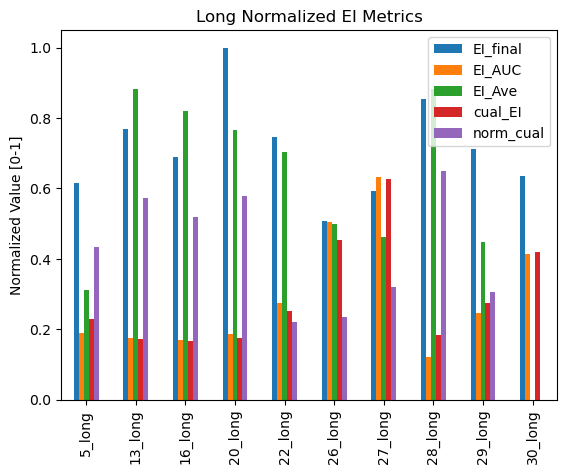

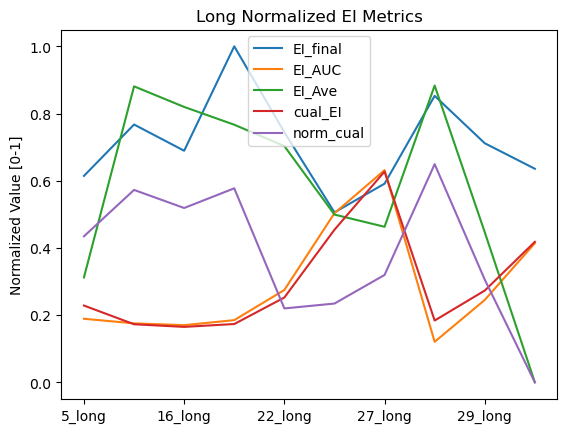

In [124]:
tempdic = {
    "EI_final": EI_final,
    "EI_AUC": EI_AUC,
    "EI_Ave": EI_Ave,
    "cual_EI": cual_EI,
    "norm_cual": norm_cual
}
temp = pd.DataFrame(tempdic)

# Min-max normalize
norm_df = (temp - temp.min()) / (temp.max() - temp.min())
norm_df = norm_df.iloc[:10]

norm_df.plot(kind='bar', title='Long Normalized EI Metrics')
plt.ylabel('Normalized Value [0-1]')
plt.show()

norm_df.plot(title='Long Normalized EI Metrics')
plt.ylabel('Normalized Value [0-1]')
plt.show()

### Short

In [125]:
EI_final = short_EI.iloc[-1]
EI_AUC = short_EI.cumsum().iloc[-1]
EI_Ave = short_EI.replace(0, np.nan).mean()

annual_last = short_EI.resample('1Y').last()
cual_EI = annual_last.cumsum().iloc[-1]
nonzero_years = (annual_last != 0).sum()
norm_cual = cual_EI / nonzero_years

/var/folders/x0/47gb5md96sdcz2ww8mdbxprh0000gn/T/ipykernel_3794/3201160154.py:5: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  annual_last = short_EI.resample('1Y').last()


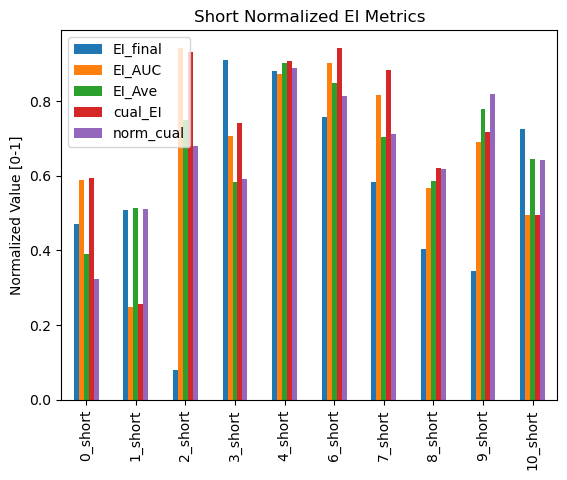

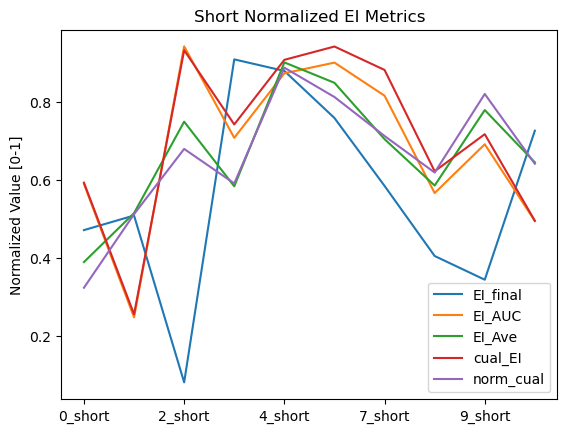

In [131]:
tempdic = {
    "EI_final": EI_final,
    "EI_AUC": EI_AUC,
    "EI_Ave": EI_Ave,
    "cual_EI": cual_EI,
    "norm_cual": norm_cual
}
temp = pd.DataFrame(tempdic)

# Min-max normalize
norm_df = (temp - temp.min()) / (temp.max() - temp.min())
norm_df = norm_df.iloc[:10]

norm_df.plot(kind='bar', title='Short Normalized EI Metrics')
plt.ylabel('Normalized Value [0-1]')
plt.show()

norm_df.plot(title='Short Normalized EI Metrics')
plt.ylabel('Normalized Value [0-1]')
plt.show()

## EI filter

In [40]:
def sharpe_ratio(returns: pd.Series) -> np.array:
    r = returns.to_numpy()
    n = np.arange(1, len(r) + 1)
    runningr = np.cumsum(r)
    runningr2 = np.cumsum(r**2)

    rmean = runningr / n
    rvar = (runningr2 / n) - rmean ** 2
    rstd = np.sqrt(np.maximum(rvar, 0))
    out = np.where(rstd == 0, np.nan, rmean / rstd * np.sqrt(252))
    out[returns == 0] = np.nan
    return out

def calmar(cumpnl: pd.Series) -> np.array:
    arr = cumpnl.to_numpy()
    top = np.maximum.accumulate(arr)
    running_dd = top - arr
    mdd = np.maximum.accumulate(running_dd)
    out = np.where(mdd != 0, arr / mdd, np.nan)
    return out

def plot_group(top, mid, bottom, df, T):
    groups = [
        ("Top 10", top),
        ("Middle 10", mid),
        ("Bottom 10", bottom)
    ]

    fig, axes = plt.subplots(3, 1, figsize=(16, 15), sharex=True)

    for ax, (title, group) in zip(axes, groups):

        # group cuvre
        for s in group:
            ax.plot(df[s], alpha=0.4, lw=1)

        # group average
        group_avg = df[group].mean(axis=1)
        group_sharpe = sharpe_ratio(group_avg)
        group_calmar = calmar(group_avg)
        ax.plot(group_avg, c='blue', lw=3,
                label=f"{title} Avg\nSharpe: {group_sharpe[-1]:.2f}, Calmar: {group_calmar[-1]:.2f}")

        # naive average
        naive_sharpe = sharpe_ratio(df['naive_ave_pnl'])
        naive_calmar = calmar(df['naive_ave_pnl'])
        ax.plot(df['naive_ave_pnl'], c='black', lw=2, ls='--', alpha=0.7,
                label=f"Naive Avg\nSharpe: {naive_sharpe[-1]:.2f}, Calmar: {naive_calmar[-1]:.2f}")

        ax.set_title(title, fontsize=14)
        ax.grid(alpha=0.3)
        ax.legend()

    plt.suptitle(T, fontsize=16)
    plt.tight_layout()
    plt.show()

### long

In [35]:
long_EI.resample('1Y').last()

/var/folders/x0/47gb5md96sdcz2ww8mdbxprh0000gn/T/ipykernel_3794/2792800591.py:1: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  long_EI.resample('1Y').last()


,5_long,13_long,16_long,20_long,22_long,26_long,27_long,28_long,29_long,30_long,...,131_long,134_long,136_long,140_long,145_long,146_long,147_long,150_long,151_long,naive_ave_pnl
2011-12-31,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.516353
2012-12-31,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.327597
2013-12-31,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.295913
2014-12-31,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.286013
2015-12-31,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.290199
2016-12-31,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.077684,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.288920
2017-12-31,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.113163,0.000000,0.000000,0.105380,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.312627
2018-12-31,0.000000,0.000000,0.000000,0.000000,0.000000,0.411717,0.411933,0.000000,0.000000,0.123116,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.453402
2019-12-31,0.000000,0.000000,0.000000,0.000000,0.000000,0.354763,0.392938,0.000000,0.000000,0.129512,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.497817
2020-12-31,0.000000,0.000000,0.000000,0.000000,0.000000,0.351009,0.406338,0.000000,0.000000,0.398977,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.479781


In [142]:
EI_final = long_EI.iloc[-1]
EI_AUC = long_EI.cumsum().iloc[-1]
EI_Ave = long_EI.replace(0, np.nan).mean()

annual_last = long_EI.resample('1Y').last()
cual_EI = annual_last.cumsum().iloc[-1]
nonzero_years = (annual_last != 0).sum()
norm_cual = cual_EI / nonzero_years

/var/folders/x0/47gb5md96sdcz2ww8mdbxprh0000gn/T/ipykernel_3794/535610552.py:5: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  annual_last = long_EI.resample('1Y').last()


In [42]:
long.shape

(3643, 49)

0.7629602623141606 0.6702631054066427
0.6264376233644527 0.5831834478640546
0.5292764823505192 0.36460084951395244


/var/folders/x0/47gb5md96sdcz2ww8mdbxprh0000gn/T/ipykernel_3794/2649286679.py:10: RuntimeWarning: invalid value encountered in divide
  out = np.where(rstd == 0, np.nan, rmean / rstd * np.sqrt(252))
/var/folders/x0/47gb5md96sdcz2ww8mdbxprh0000gn/T/ipykernel_3794/2649286679.py:19: RuntimeWarning: divide by zero encountered in divide
  out = np.where(mdd != 0, arr / mdd, np.nan)
/var/folders/x0/47gb5md96sdcz2ww8mdbxprh0000gn/T/ipykernel_3794/2649286679.py:19: RuntimeWarning: invalid value encountered in divide
  out = np.where(mdd != 0, arr / mdd, np.nan)
/var/folders/x0/47gb5md96sdcz2ww8mdbxprh0000gn/T/ipykernel_3794/2649286679.py:10: RuntimeWarning: divide by zero encountered in divide
  out = np.where(rstd == 0, np.nan, rmean / rstd * np.sqrt(252))
/var/folders/x0/47gb5md96sdcz2ww8mdbxprh0000gn/T/ipykernel_3794/2649286679.py:10: RuntimeWarning: divide by zero encountered in divide
  out = np.where(rstd == 0, np.nan, rmean / rstd * np.sqrt(252))
/var/folders/x0/47gb5md96sdcz2ww8mdbxprh

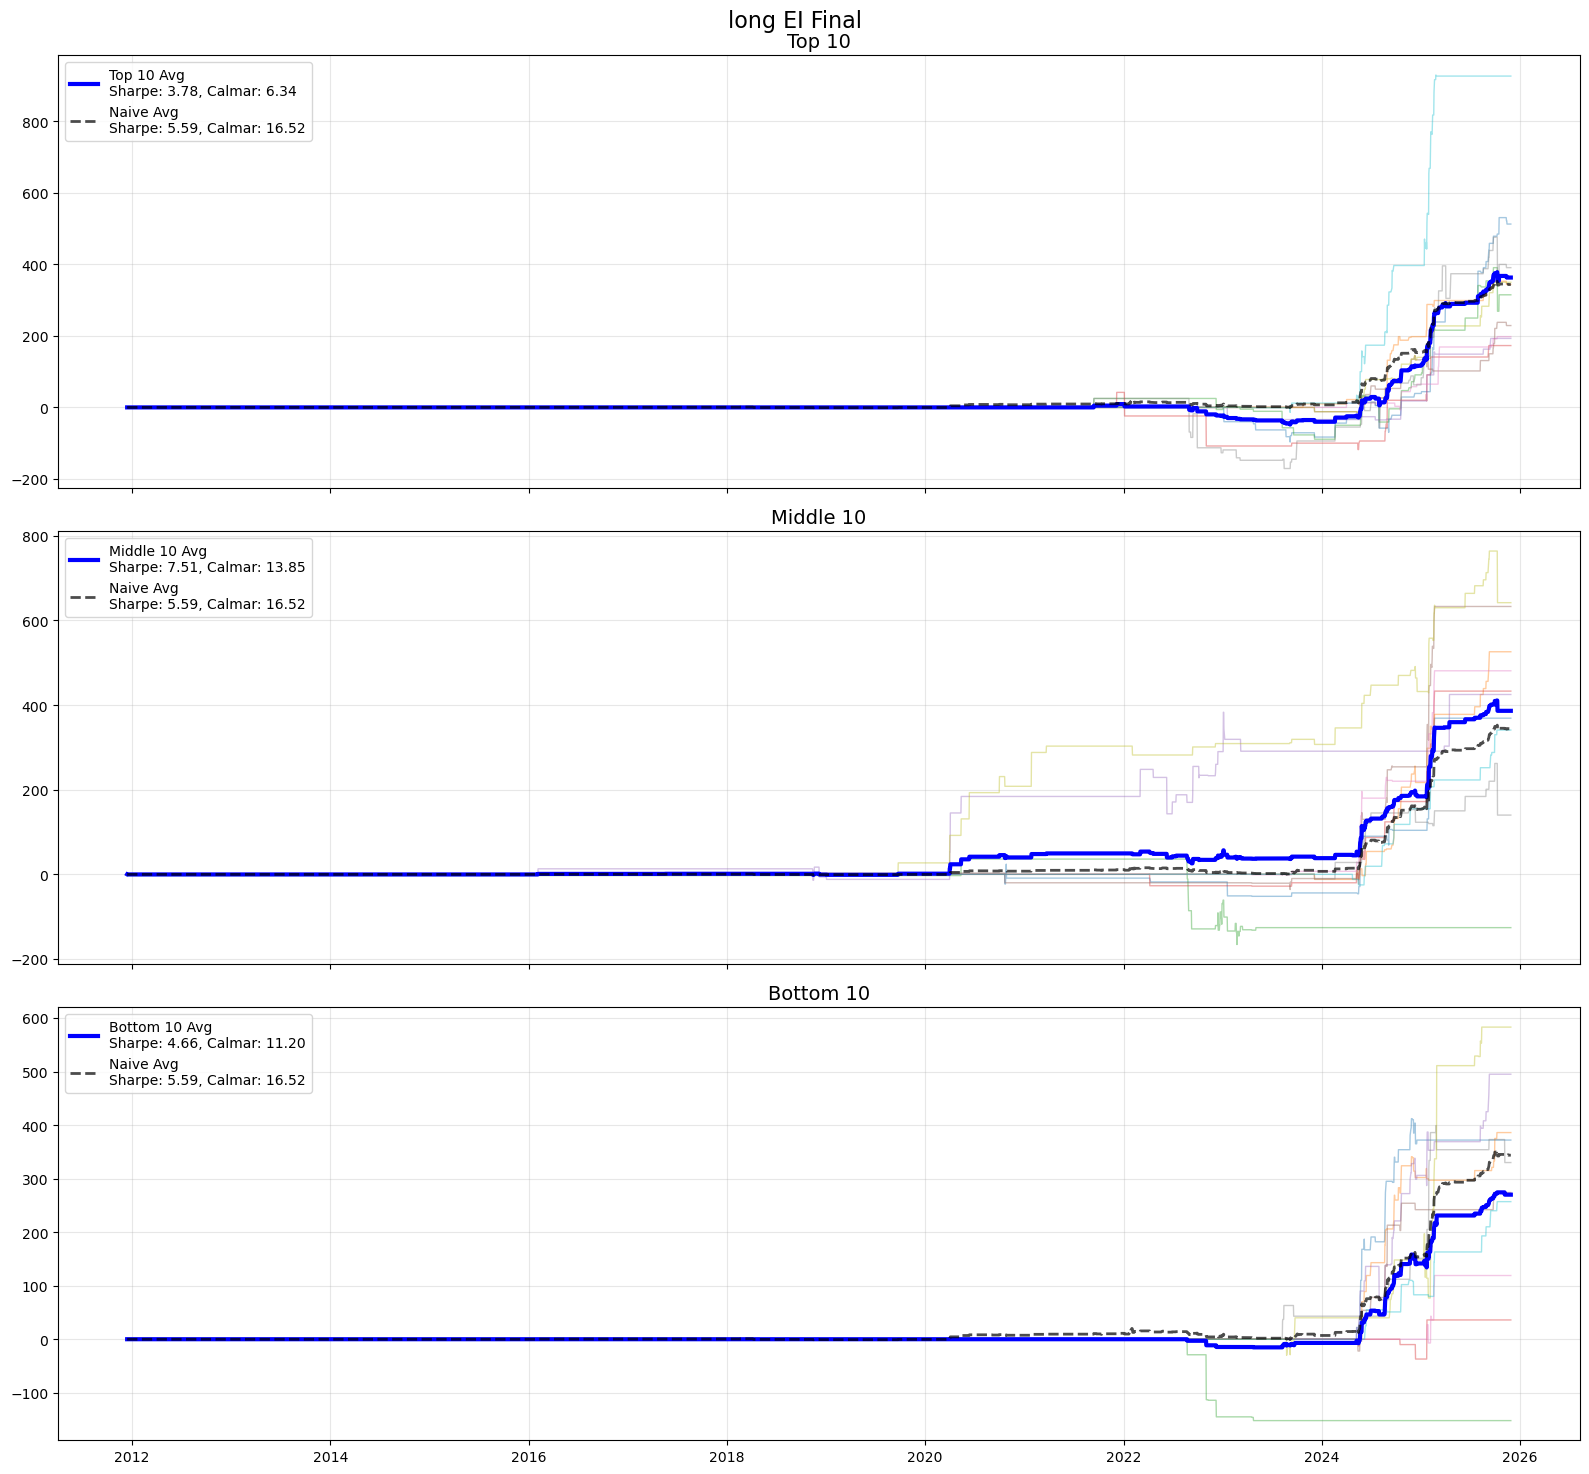

In [ ]:
filter = EI_final.drop(index=['naive_ave_pnl'])

top10 = filter.nlargest(10).index
print(EI_final[top10].max(), EI_final[top10].min())
mid10 = filter.nlargest(30).index.difference(filter.nlargest(20).index)
print(EI_final[mid10].max(), EI_final[mid10].min())
bottom10 = filter.nsmallest(10).index
print(EI_final[bottom10].max(), EI_final[bottom10].min())

plot_group(top10, mid10, bottom10, long, 'long EI Final')

72.51328972833244 20.907236195322707
16.231918681521915 11.783507604236362
9.02908258915527 3.1036655513058236


/var/folders/x0/47gb5md96sdcz2ww8mdbxprh0000gn/T/ipykernel_3794/2649286679.py:10: RuntimeWarning: divide by zero encountered in divide
  out = np.where(rstd == 0, np.nan, rmean / rstd * np.sqrt(252))
/var/folders/x0/47gb5md96sdcz2ww8mdbxprh0000gn/T/ipykernel_3794/2649286679.py:19: RuntimeWarning: divide by zero encountered in divide
  out = np.where(mdd != 0, arr / mdd, np.nan)
/var/folders/x0/47gb5md96sdcz2ww8mdbxprh0000gn/T/ipykernel_3794/2649286679.py:10: RuntimeWarning: invalid value encountered in divide
  out = np.where(rstd == 0, np.nan, rmean / rstd * np.sqrt(252))
/var/folders/x0/47gb5md96sdcz2ww8mdbxprh0000gn/T/ipykernel_3794/2649286679.py:19: RuntimeWarning: divide by zero encountered in divide
  out = np.where(mdd != 0, arr / mdd, np.nan)
/var/folders/x0/47gb5md96sdcz2ww8mdbxprh0000gn/T/ipykernel_3794/2649286679.py:19: RuntimeWarning: invalid value encountered in divide
  out = np.where(mdd != 0, arr / mdd, np.nan)
/var/folders/x0/47gb5md96sdcz2ww8mdbxprh0000gn/T/ipykernel_

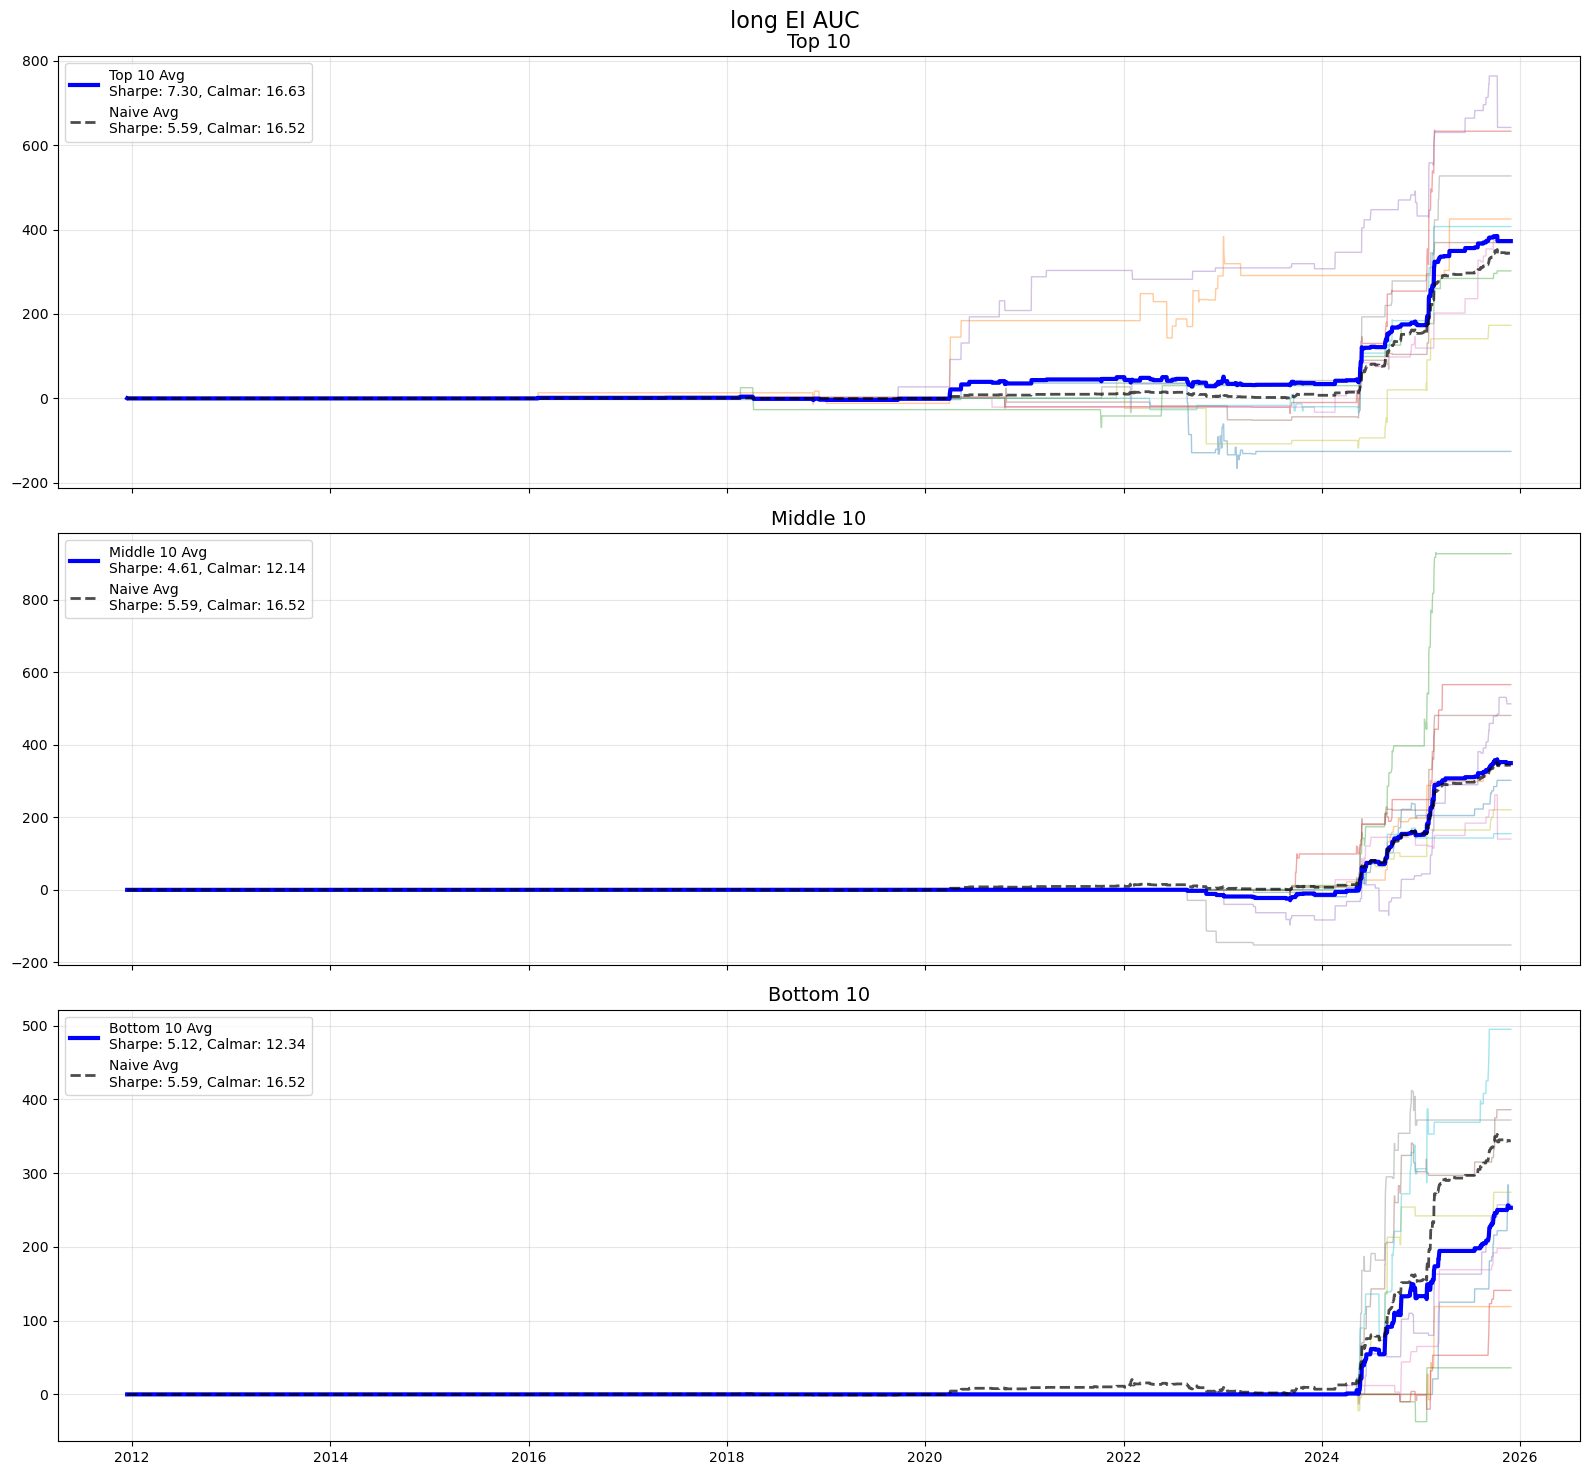

In [146]:
filter = EI_AUC.drop(index=['naive_ave_pnl'])
top10 = filter.nlargest(10).index
mid10 = filter.nlargest(30).index.difference(filter.nlargest(20).index)
bottom10 = filter.nsmallest(10).index

top10 = filter.nlargest(10).index
print(EI_AUC[top10].max(), EI_AUC[top10].min())
mid10 = filter.nlargest(30).index.difference(filter.nlargest(20).index)
print(EI_AUC[mid10].max(), EI_AUC[mid10].min())
bottom10 = filter.nsmallest(10).index
print(EI_AUC[bottom10].max(), EI_AUC[bottom10].min())


plot_group(top10, mid10, bottom10, long, 'long EI AUC')

0.5004571253632231 0.46212361781078704
0.43162672457340695 0.40466553565874513
0.3909025290475118 0.3091496113321791


/var/folders/x0/47gb5md96sdcz2ww8mdbxprh0000gn/T/ipykernel_3794/2649286679.py:10: RuntimeWarning: invalid value encountered in divide
  out = np.where(rstd == 0, np.nan, rmean / rstd * np.sqrt(252))
/var/folders/x0/47gb5md96sdcz2ww8mdbxprh0000gn/T/ipykernel_3794/2649286679.py:19: RuntimeWarning: invalid value encountered in divide
  out = np.where(mdd != 0, arr / mdd, np.nan)
/var/folders/x0/47gb5md96sdcz2ww8mdbxprh0000gn/T/ipykernel_3794/2649286679.py:10: RuntimeWarning: divide by zero encountered in divide
  out = np.where(rstd == 0, np.nan, rmean / rstd * np.sqrt(252))
/var/folders/x0/47gb5md96sdcz2ww8mdbxprh0000gn/T/ipykernel_3794/2649286679.py:19: RuntimeWarning: divide by zero encountered in divide
  out = np.where(mdd != 0, arr / mdd, np.nan)
/var/folders/x0/47gb5md96sdcz2ww8mdbxprh0000gn/T/ipykernel_3794/2649286679.py:10: RuntimeWarning: divide by zero encountered in divide
  out = np.where(rstd == 0, np.nan, rmean / rstd * np.sqrt(252))
/var/folders/x0/47gb5md96sdcz2ww8mdbxprh

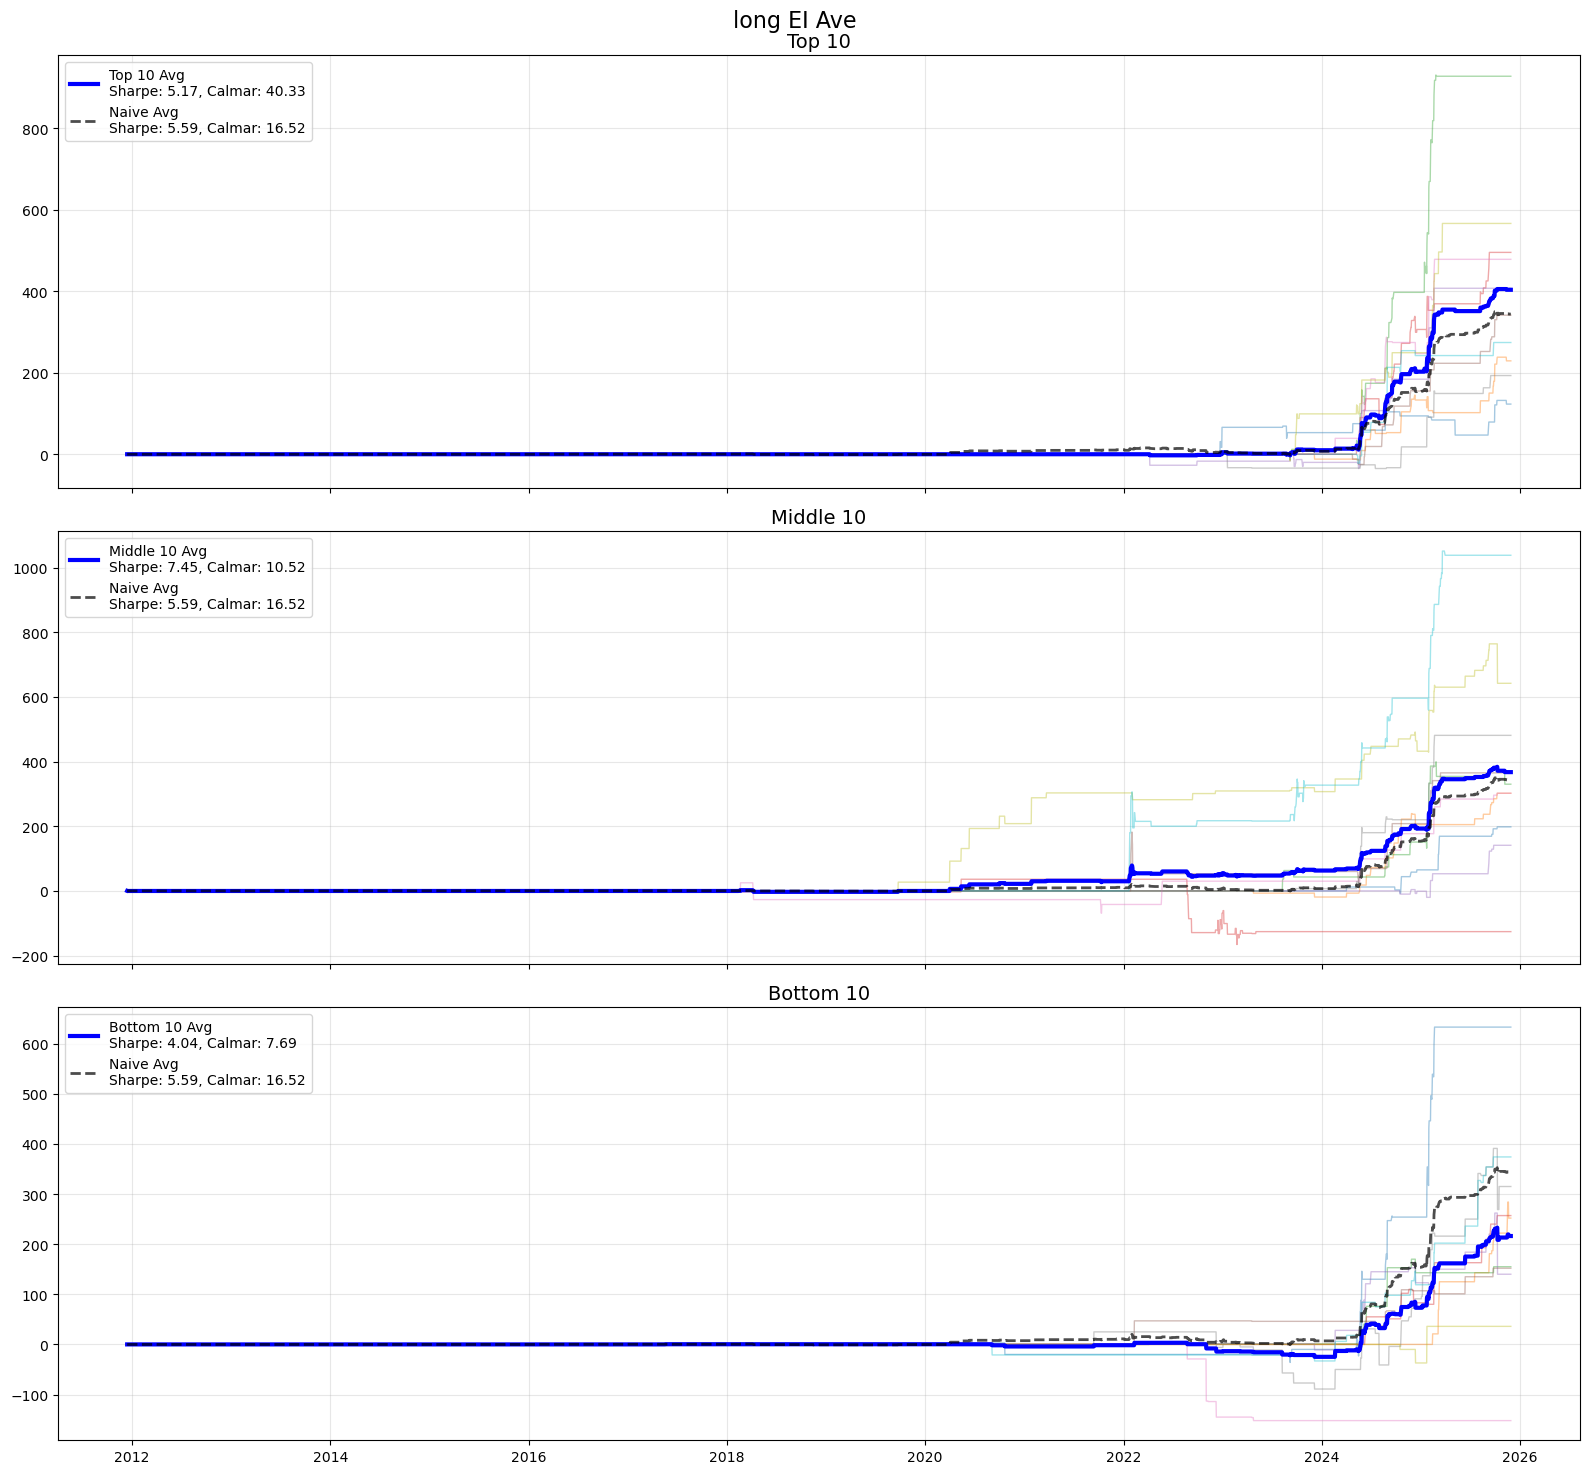

In [147]:
filter = EI_Ave.drop(index=['naive_ave_pnl'])
top10 = filter.nlargest(10).index
mid10 = filter.nlargest(30).index.difference(filter.nlargest(20).index)
bottom10 = filter.nsmallest(10).index

top10 = filter.nlargest(10).index
print(EI_Ave[top10].max(), EI_Ave[top10].min())
mid10 = filter.nlargest(30).index.difference(filter.nlargest(20).index)
print(EI_Ave[mid10].max(), EI_Ave[mid10].min())
bottom10 = filter.nsmallest(10).index
print(EI_Ave[bottom10].max(), EI_Ave[bottom10].min())

plot_group(top10, mid10, bottom10, long, 'long EI Ave')

/var/folders/x0/47gb5md96sdcz2ww8mdbxprh0000gn/T/ipykernel_3794/2649286679.py:10: RuntimeWarning: divide by zero encountered in divide
  out = np.where(rstd == 0, np.nan, rmean / rstd * np.sqrt(252))
/var/folders/x0/47gb5md96sdcz2ww8mdbxprh0000gn/T/ipykernel_3794/2649286679.py:19: RuntimeWarning: divide by zero encountered in divide
  out = np.where(mdd != 0, arr / mdd, np.nan)
/var/folders/x0/47gb5md96sdcz2ww8mdbxprh0000gn/T/ipykernel_3794/2649286679.py:10: RuntimeWarning: invalid value encountered in divide
  out = np.where(rstd == 0, np.nan, rmean / rstd * np.sqrt(252))
/var/folders/x0/47gb5md96sdcz2ww8mdbxprh0000gn/T/ipykernel_3794/2649286679.py:19: RuntimeWarning: divide by zero encountered in divide
  out = np.where(mdd != 0, arr / mdd, np.nan)
/var/folders/x0/47gb5md96sdcz2ww8mdbxprh0000gn/T/ipykernel_3794/2649286679.py:19: RuntimeWarning: invalid value encountered in divide
  out = np.where(mdd != 0, arr / mdd, np.nan)
/var/folders/x0/47gb5md96sdcz2ww8mdbxprh0000gn/T/ipykernel_

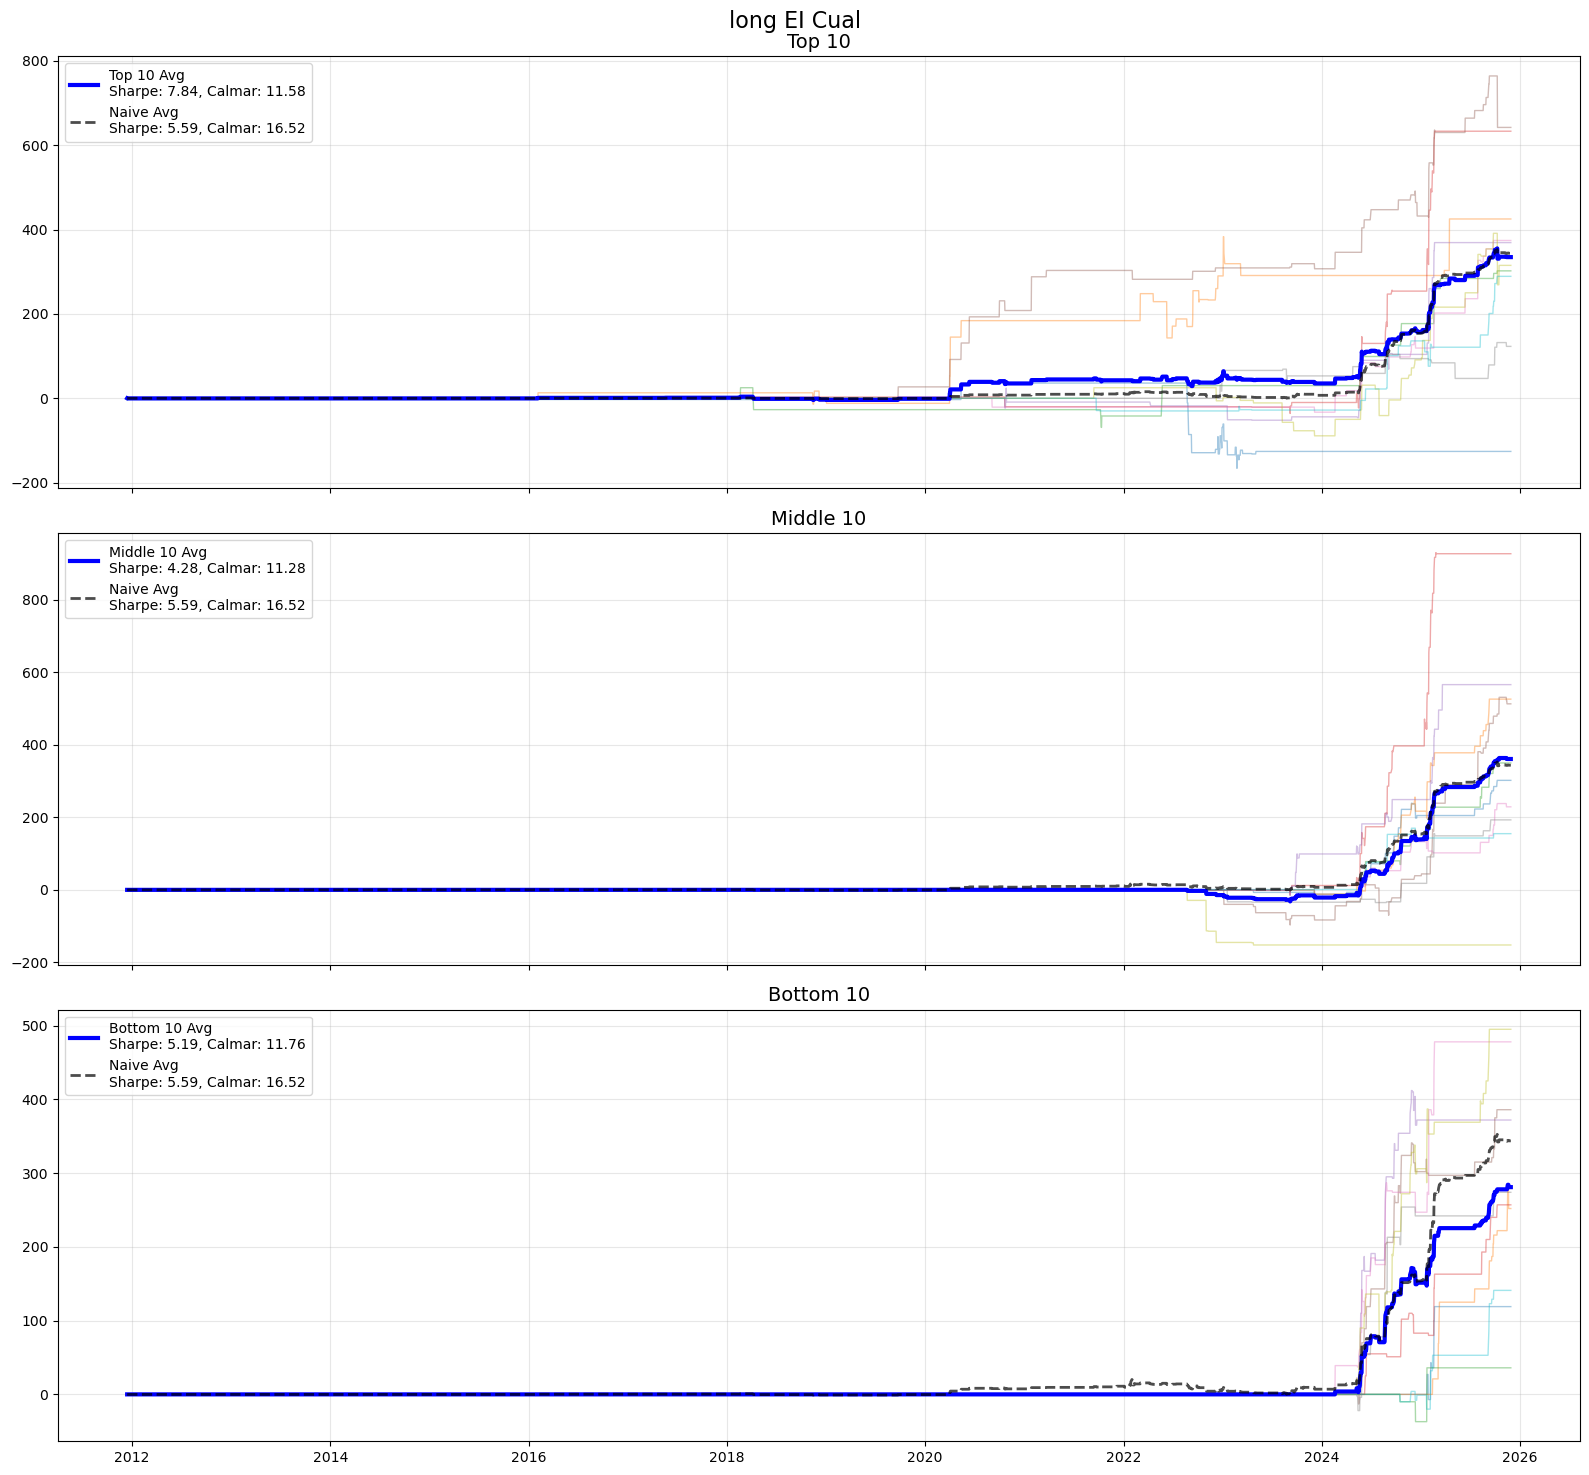

In [57]:
filter = cual_EI.drop(index=['naive_ave_pnl'])
top10 = filter.nlargest(10).index
mid10 = filter.nlargest(30).index.difference(filter.nlargest(20).index)
bottom10 = filter.nsmallest(10).index

plot_group(top10, mid10, bottom10, long, 'long EI Cual')

/var/folders/x0/47gb5md96sdcz2ww8mdbxprh0000gn/T/ipykernel_3794/2649286679.py:10: RuntimeWarning: invalid value encountered in divide
  out = np.where(rstd == 0, np.nan, rmean / rstd * np.sqrt(252))
/var/folders/x0/47gb5md96sdcz2ww8mdbxprh0000gn/T/ipykernel_3794/2649286679.py:19: RuntimeWarning: invalid value encountered in divide
  out = np.where(mdd != 0, arr / mdd, np.nan)
/var/folders/x0/47gb5md96sdcz2ww8mdbxprh0000gn/T/ipykernel_3794/2649286679.py:10: RuntimeWarning: divide by zero encountered in divide
  out = np.where(rstd == 0, np.nan, rmean / rstd * np.sqrt(252))
/var/folders/x0/47gb5md96sdcz2ww8mdbxprh0000gn/T/ipykernel_3794/2649286679.py:19: RuntimeWarning: divide by zero encountered in divide
  out = np.where(mdd != 0, arr / mdd, np.nan)
/var/folders/x0/47gb5md96sdcz2ww8mdbxprh0000gn/T/ipykernel_3794/2649286679.py:10: RuntimeWarning: divide by zero encountered in divide
  out = np.where(rstd == 0, np.nan, rmean / rstd * np.sqrt(252))
/var/folders/x0/47gb5md96sdcz2ww8mdbxprh

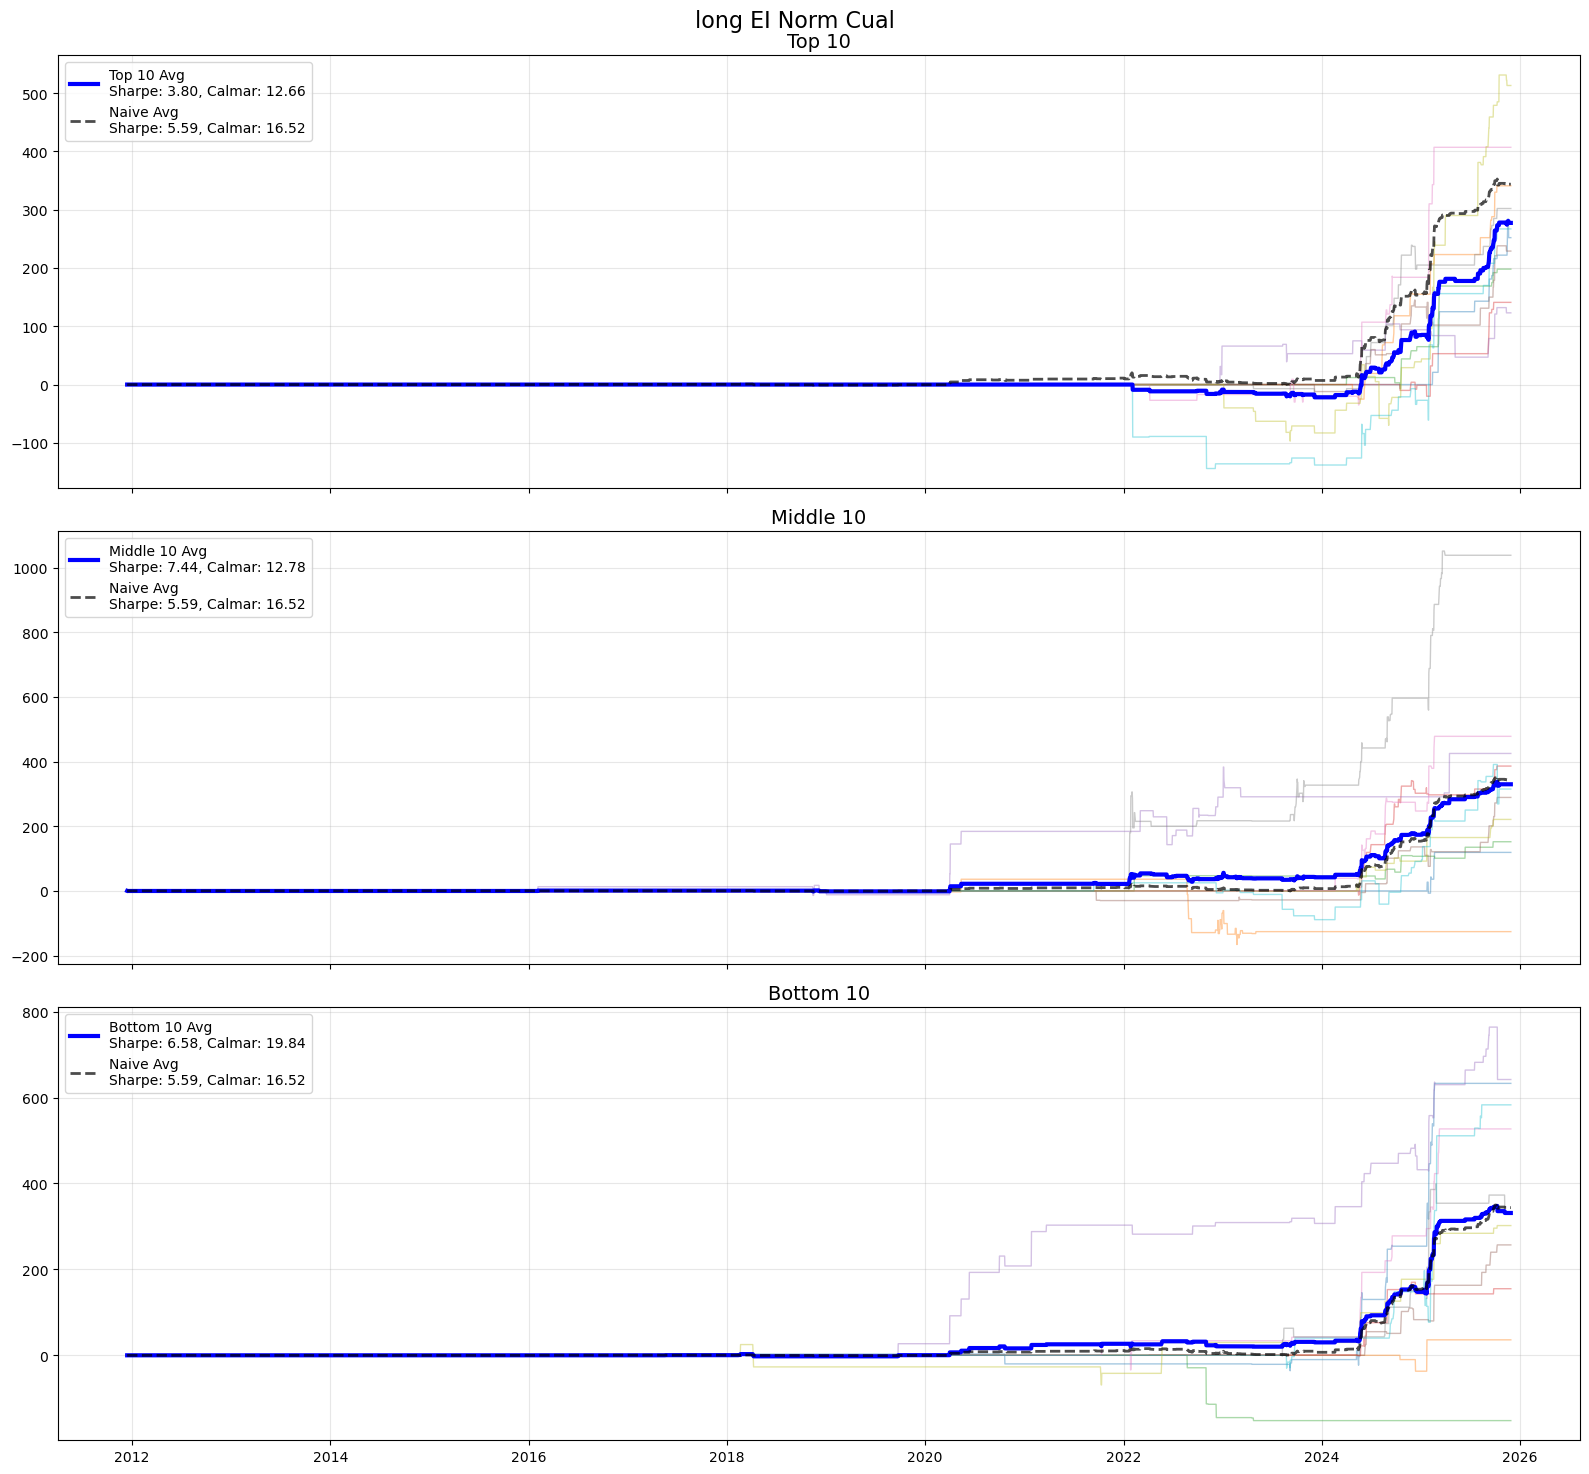

In [58]:
filter = norm_cual.drop(index=['naive_ave_pnl'])
top10 = filter.nlargest(10).index
mid10 = filter.nlargest(30).index.difference(filter.nlargest(20).index)
bottom10 = filter.nsmallest(10).index

plot_group(top10, mid10, bottom10, long, 'long EI Norm Cual')

### short

In [61]:
EI_final = short_EI.iloc[-1]
EI_AUC = short_EI.cumsum().iloc[-1]
EI_Ave = short_EI.replace(0, np.nan).mean()

annual_last = short_EI.resample('1Y').last()
cual_EI = annual_last.cumsum().iloc[-1]
nonzero_years = (annual_last != 0).sum()
norm_cual = cual_EI / nonzero_years

/var/folders/x0/47gb5md96sdcz2ww8mdbxprh0000gn/T/ipykernel_3794/3201160154.py:5: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  annual_last = short_EI.resample('1Y').last()


/var/folders/x0/47gb5md96sdcz2ww8mdbxprh0000gn/T/ipykernel_3794/2649286679.py:10: RuntimeWarning: invalid value encountered in divide
  out = np.where(rstd == 0, np.nan, rmean / rstd * np.sqrt(252))
/var/folders/x0/47gb5md96sdcz2ww8mdbxprh0000gn/T/ipykernel_3794/2649286679.py:19: RuntimeWarning: divide by zero encountered in divide
  out = np.where(mdd != 0, arr / mdd, np.nan)
/var/folders/x0/47gb5md96sdcz2ww8mdbxprh0000gn/T/ipykernel_3794/2649286679.py:19: RuntimeWarning: invalid value encountered in divide
  out = np.where(mdd != 0, arr / mdd, np.nan)
/var/folders/x0/47gb5md96sdcz2ww8mdbxprh0000gn/T/ipykernel_3794/2649286679.py:10: RuntimeWarning: divide by zero encountered in divide
  out = np.where(rstd == 0, np.nan, rmean / rstd * np.sqrt(252))
/var/folders/x0/47gb5md96sdcz2ww8mdbxprh0000gn/T/ipykernel_3794/2649286679.py:10: RuntimeWarning: divide by zero encountered in divide
  out = np.where(rstd == 0, np.nan, rmean / rstd * np.sqrt(252))
/var/folders/x0/47gb5md96sdcz2ww8mdbxprh

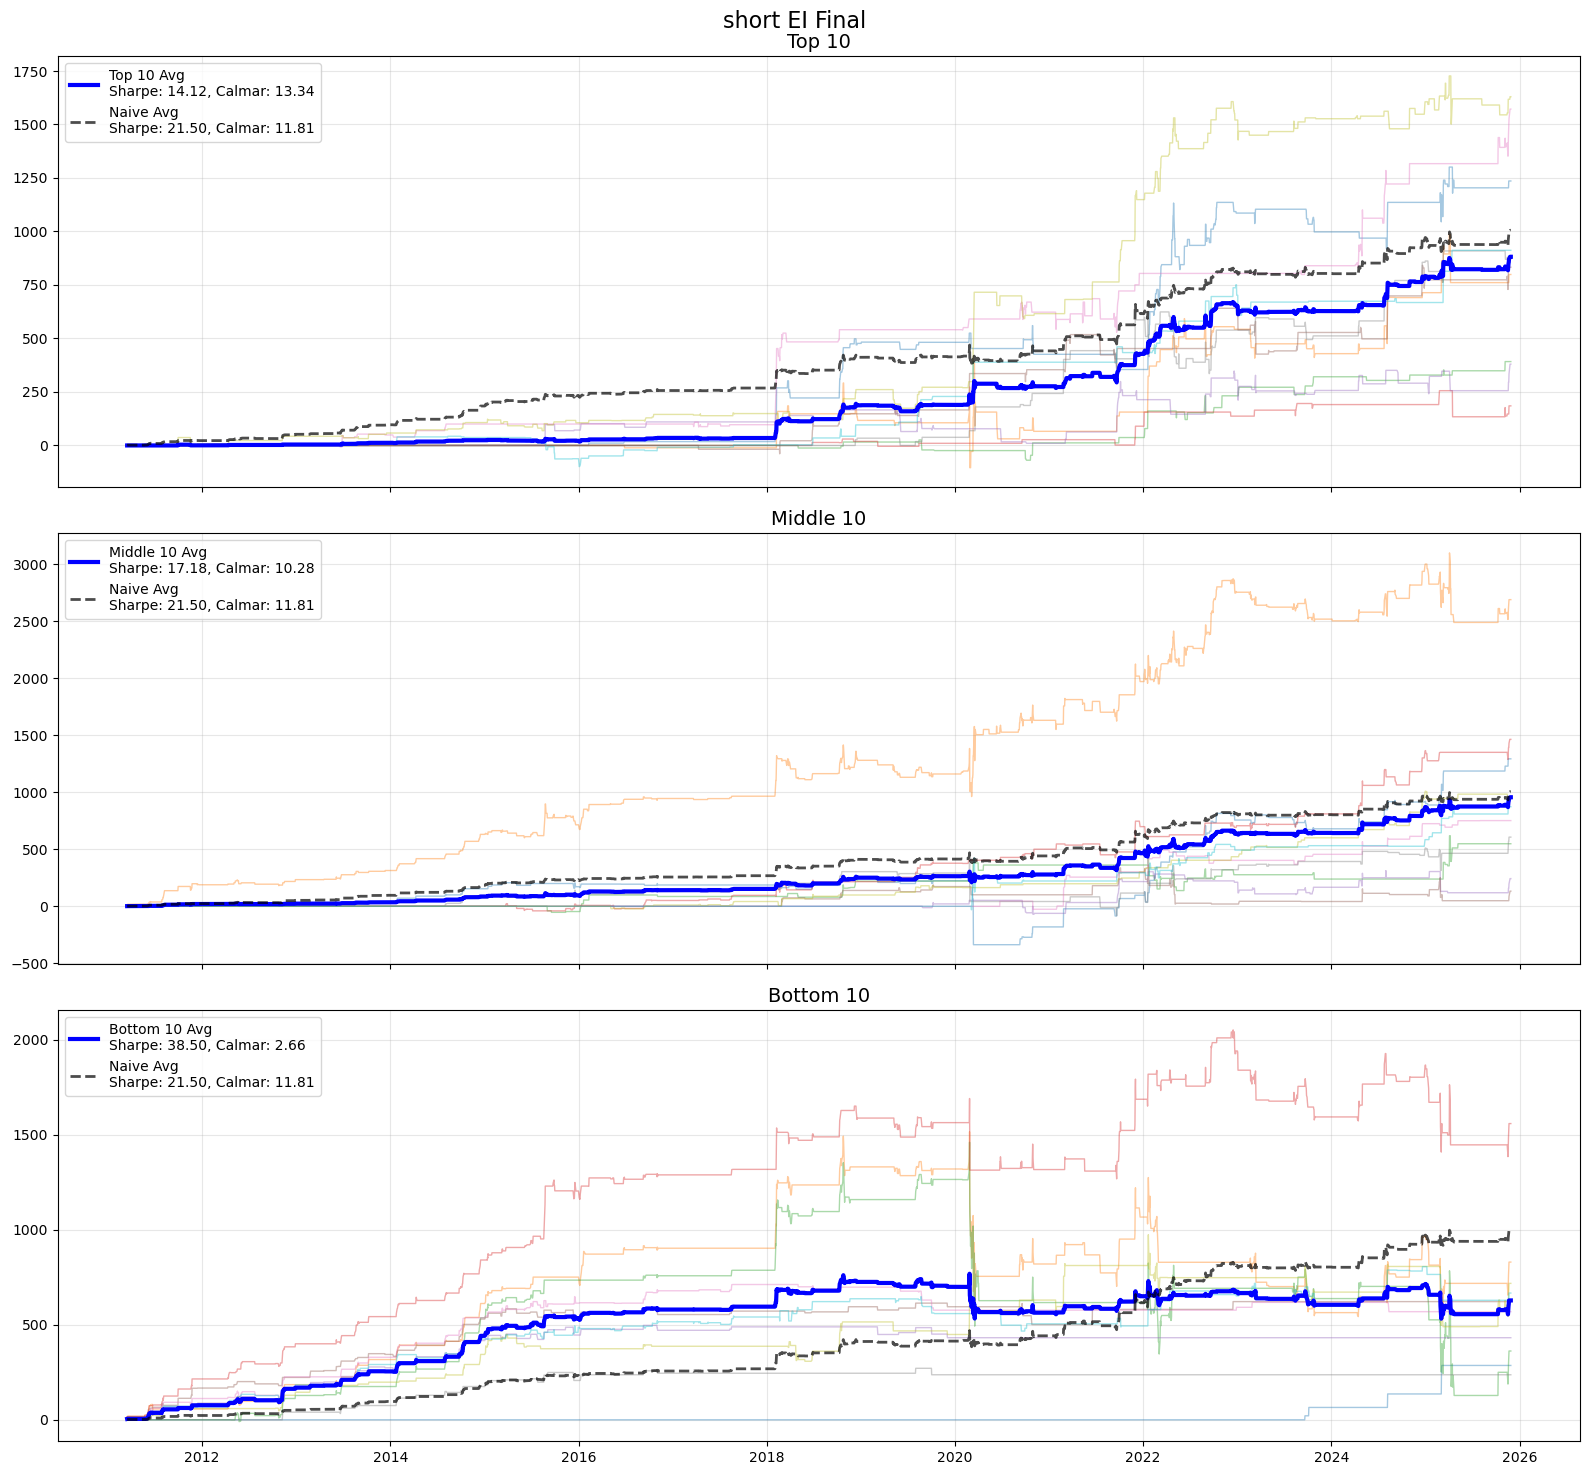

In [64]:
filter = EI_final.drop(index=['naive_ave_pnl'])
top10 = filter.nlargest(10).index
mid10 = filter.nlargest(65).index.difference(filter.nlargest(55).index)
bottom10 = filter.nsmallest(10).index

plot_group(top10, mid10, bottom10, short, 'short EI Final')

/var/folders/x0/47gb5md96sdcz2ww8mdbxprh0000gn/T/ipykernel_3794/2649286679.py:10: RuntimeWarning: divide by zero encountered in divide
  out = np.where(rstd == 0, np.nan, rmean / rstd * np.sqrt(252))
/var/folders/x0/47gb5md96sdcz2ww8mdbxprh0000gn/T/ipykernel_3794/2649286679.py:19: RuntimeWarning: divide by zero encountered in divide
  out = np.where(mdd != 0, arr / mdd, np.nan)
/var/folders/x0/47gb5md96sdcz2ww8mdbxprh0000gn/T/ipykernel_3794/2649286679.py:10: RuntimeWarning: invalid value encountered in divide
  out = np.where(rstd == 0, np.nan, rmean / rstd * np.sqrt(252))
/var/folders/x0/47gb5md96sdcz2ww8mdbxprh0000gn/T/ipykernel_3794/2649286679.py:19: RuntimeWarning: invalid value encountered in divide
  out = np.where(mdd != 0, arr / mdd, np.nan)
/var/folders/x0/47gb5md96sdcz2ww8mdbxprh0000gn/T/ipykernel_3794/2649286679.py:10: RuntimeWarning: divide by zero encountered in divide
  out = np.where(rstd == 0, np.nan, rmean / rstd * np.sqrt(252))
/var/folders/x0/47gb5md96sdcz2ww8mdbxprh

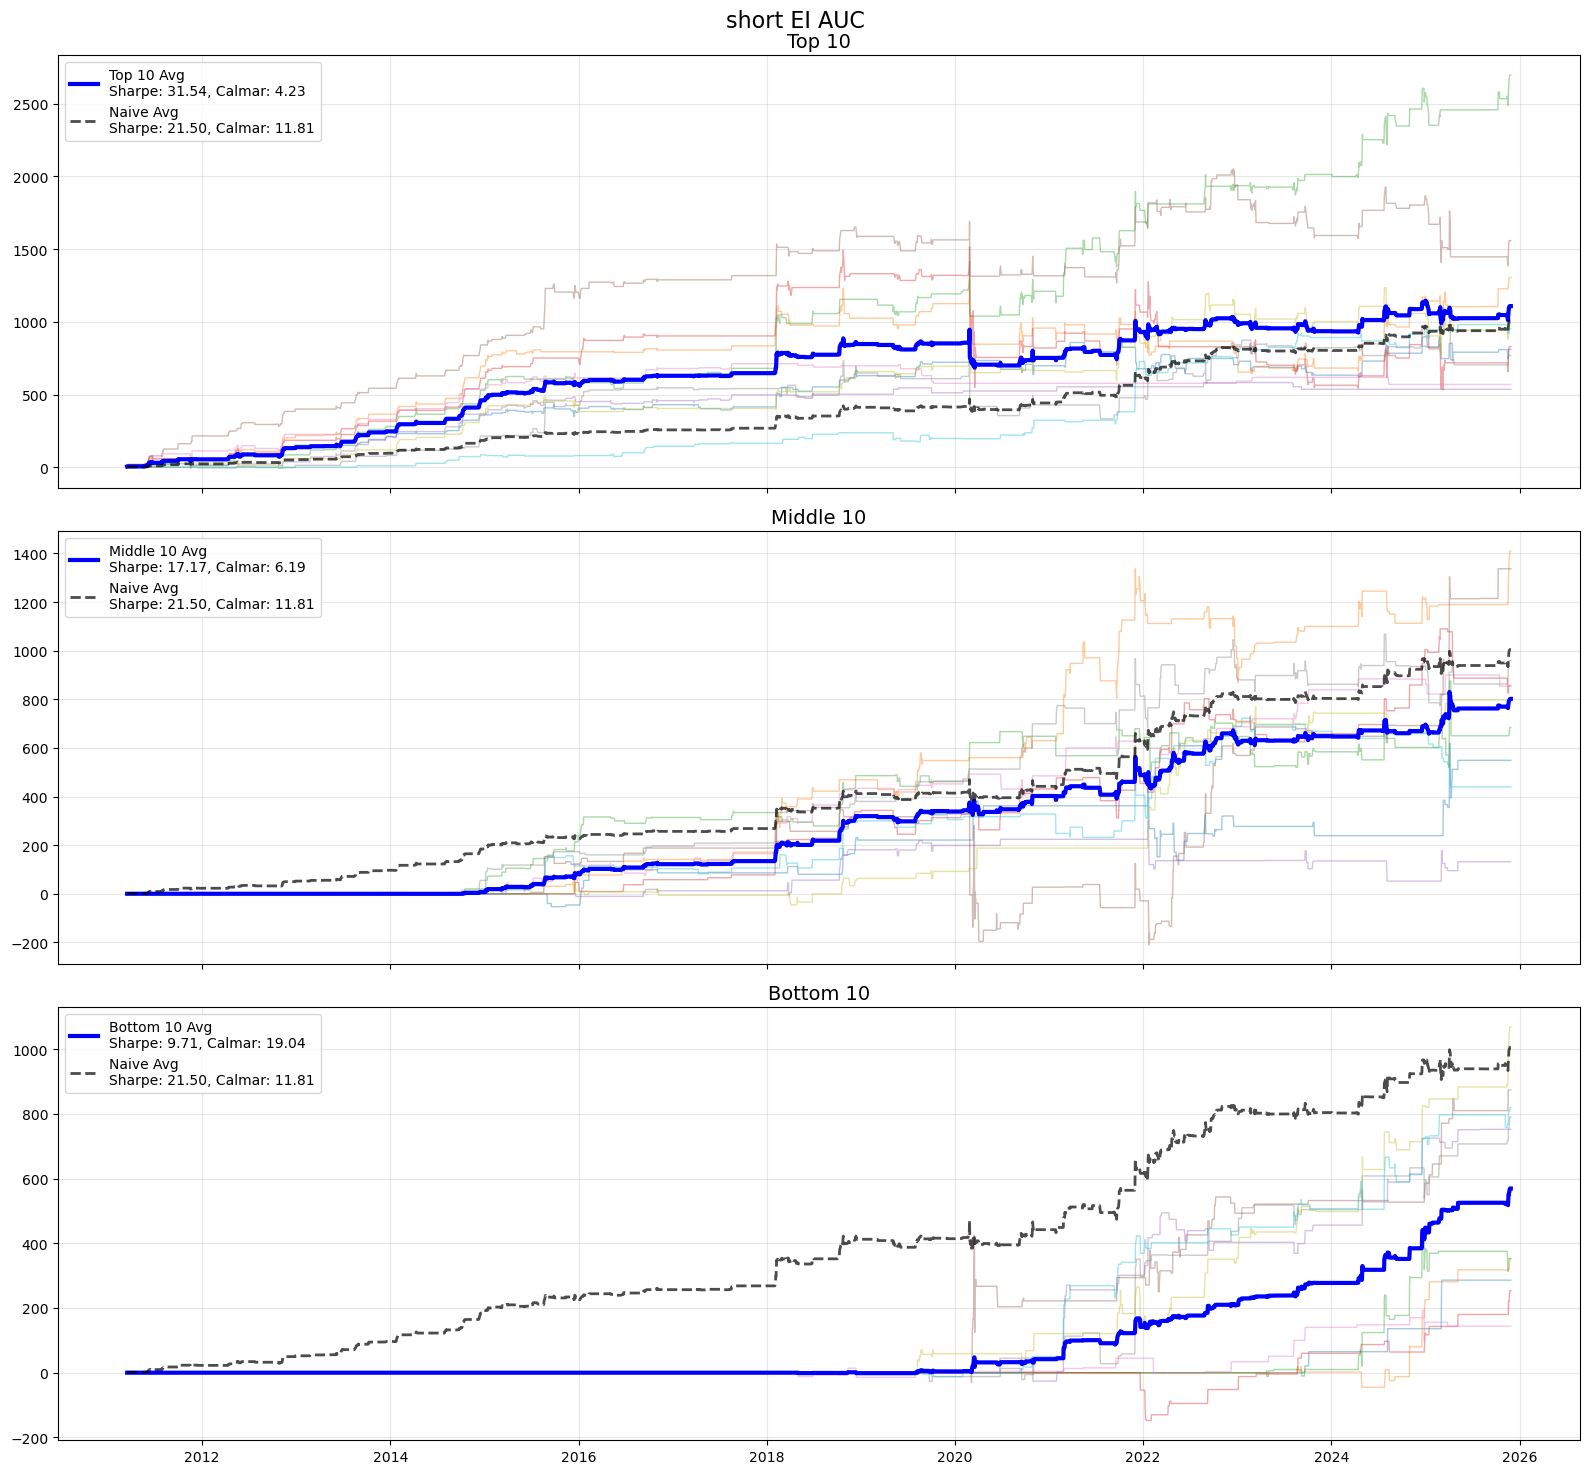

In [63]:
filter = EI_AUC.drop(index=['naive_ave_pnl'])
top10 = filter.nlargest(10).index
mid10 = filter.nlargest(65).index.difference(filter.nlargest(55).index)
bottom10 = filter.nsmallest(10).index

plot_group(top10, mid10, bottom10, short, 'short EI AUC')

/var/folders/x0/47gb5md96sdcz2ww8mdbxprh0000gn/T/ipykernel_3794/2649286679.py:10: RuntimeWarning: invalid value encountered in divide
  out = np.where(rstd == 0, np.nan, rmean / rstd * np.sqrt(252))
/var/folders/x0/47gb5md96sdcz2ww8mdbxprh0000gn/T/ipykernel_3794/2649286679.py:19: RuntimeWarning: divide by zero encountered in divide
  out = np.where(mdd != 0, arr / mdd, np.nan)
/var/folders/x0/47gb5md96sdcz2ww8mdbxprh0000gn/T/ipykernel_3794/2649286679.py:19: RuntimeWarning: invalid value encountered in divide
  out = np.where(mdd != 0, arr / mdd, np.nan)
/var/folders/x0/47gb5md96sdcz2ww8mdbxprh0000gn/T/ipykernel_3794/2649286679.py:10: RuntimeWarning: divide by zero encountered in divide
  out = np.where(rstd == 0, np.nan, rmean / rstd * np.sqrt(252))
/var/folders/x0/47gb5md96sdcz2ww8mdbxprh0000gn/T/ipykernel_3794/2649286679.py:10: RuntimeWarning: invalid value encountered in divide
  out = np.where(rstd == 0, np.nan, rmean / rstd * np.sqrt(252))
/var/folders/x0/47gb5md96sdcz2ww8mdbxprh0

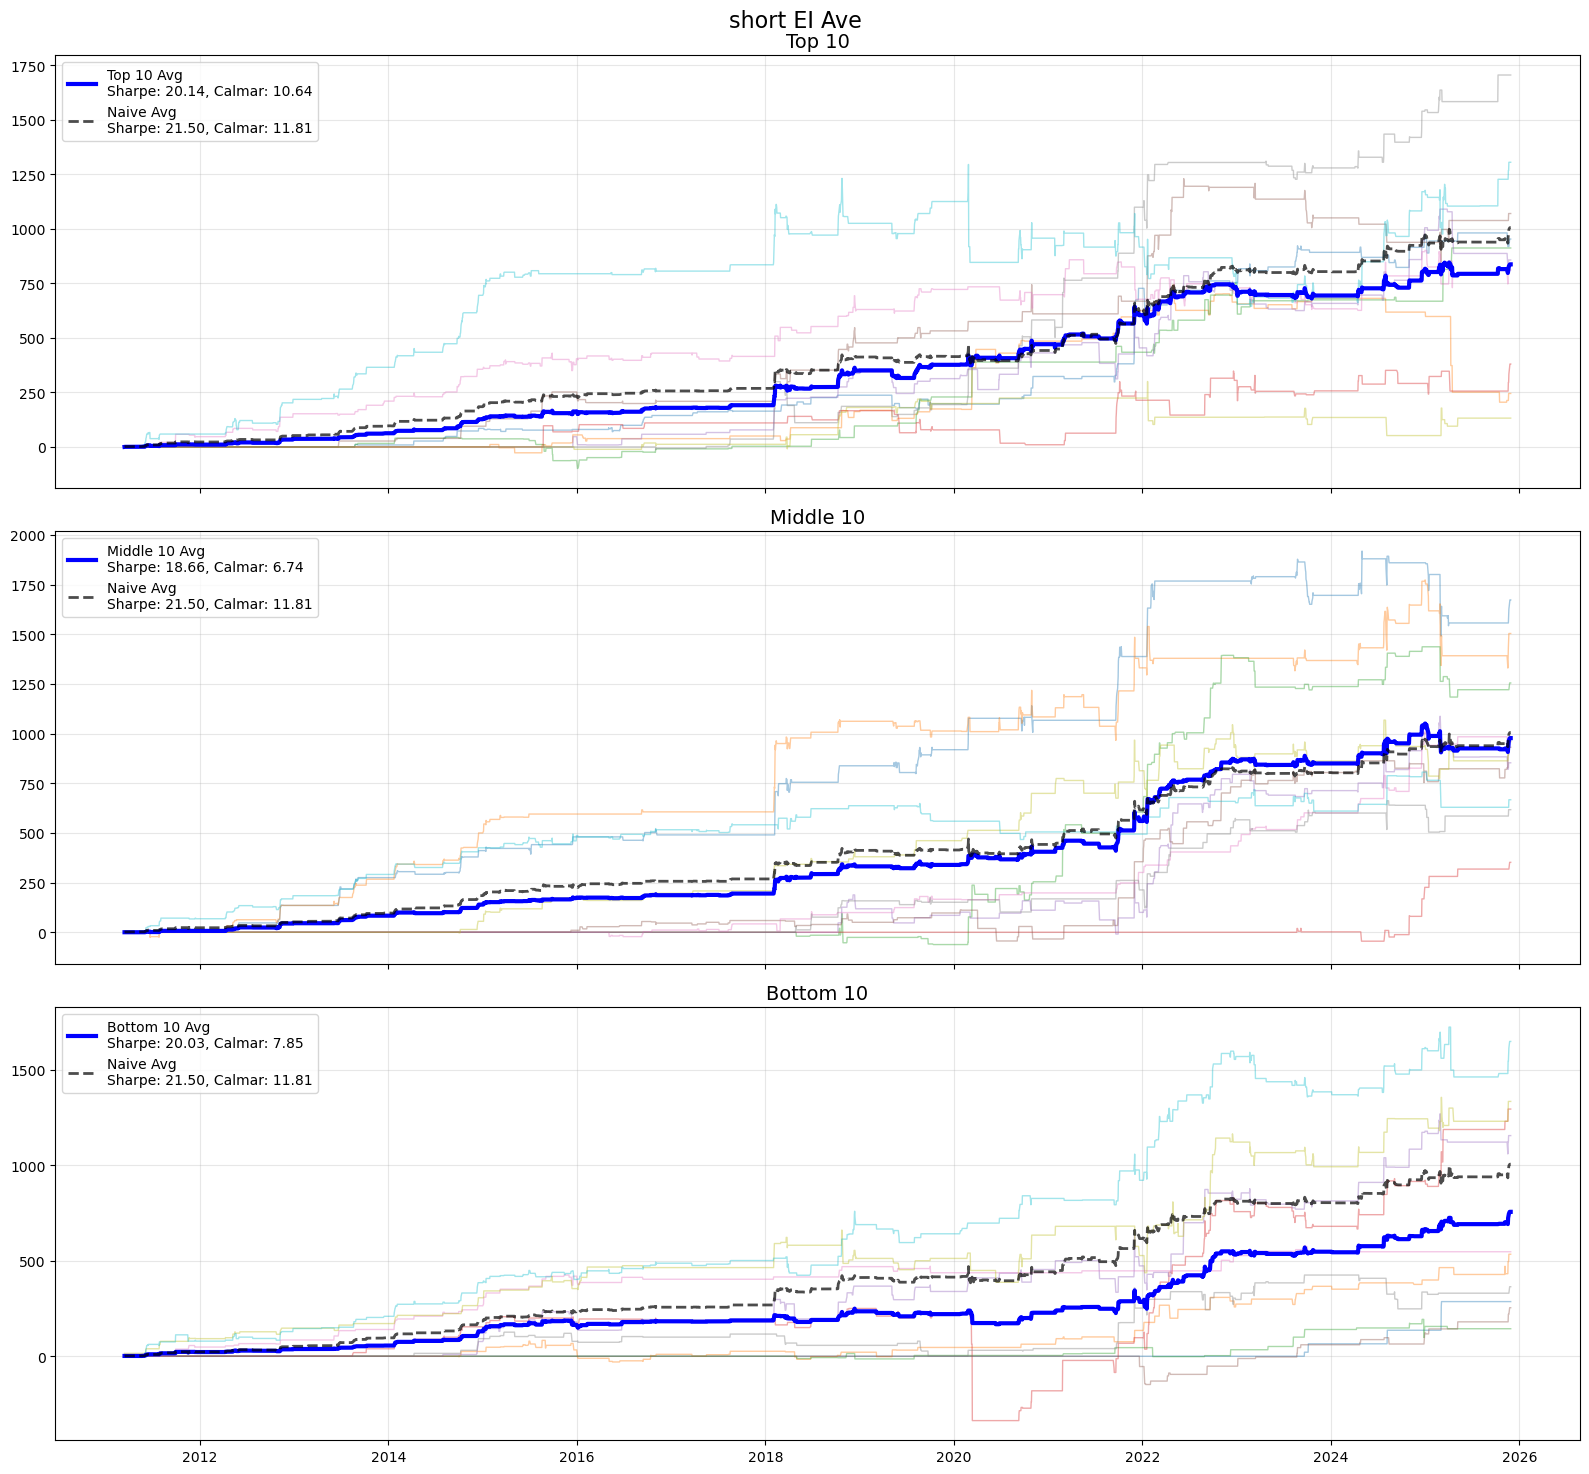

In [65]:
filter = EI_Ave.drop(index=['naive_ave_pnl'])
top10 = filter.nlargest(10).index
mid10 = filter.nlargest(65).index.difference(filter.nlargest(55).index)
bottom10 = filter.nsmallest(10).index

plot_group(top10, mid10, bottom10, short, 'short EI Ave')

/var/folders/x0/47gb5md96sdcz2ww8mdbxprh0000gn/T/ipykernel_3794/2649286679.py:10: RuntimeWarning: divide by zero encountered in divide
  out = np.where(rstd == 0, np.nan, rmean / rstd * np.sqrt(252))
/var/folders/x0/47gb5md96sdcz2ww8mdbxprh0000gn/T/ipykernel_3794/2649286679.py:19: RuntimeWarning: divide by zero encountered in divide
  out = np.where(mdd != 0, arr / mdd, np.nan)
/var/folders/x0/47gb5md96sdcz2ww8mdbxprh0000gn/T/ipykernel_3794/2649286679.py:10: RuntimeWarning: invalid value encountered in divide
  out = np.where(rstd == 0, np.nan, rmean / rstd * np.sqrt(252))
/var/folders/x0/47gb5md96sdcz2ww8mdbxprh0000gn/T/ipykernel_3794/2649286679.py:19: RuntimeWarning: invalid value encountered in divide
  out = np.where(mdd != 0, arr / mdd, np.nan)
/var/folders/x0/47gb5md96sdcz2ww8mdbxprh0000gn/T/ipykernel_3794/2649286679.py:10: RuntimeWarning: divide by zero encountered in divide
  out = np.where(rstd == 0, np.nan, rmean / rstd * np.sqrt(252))
/var/folders/x0/47gb5md96sdcz2ww8mdbxprh

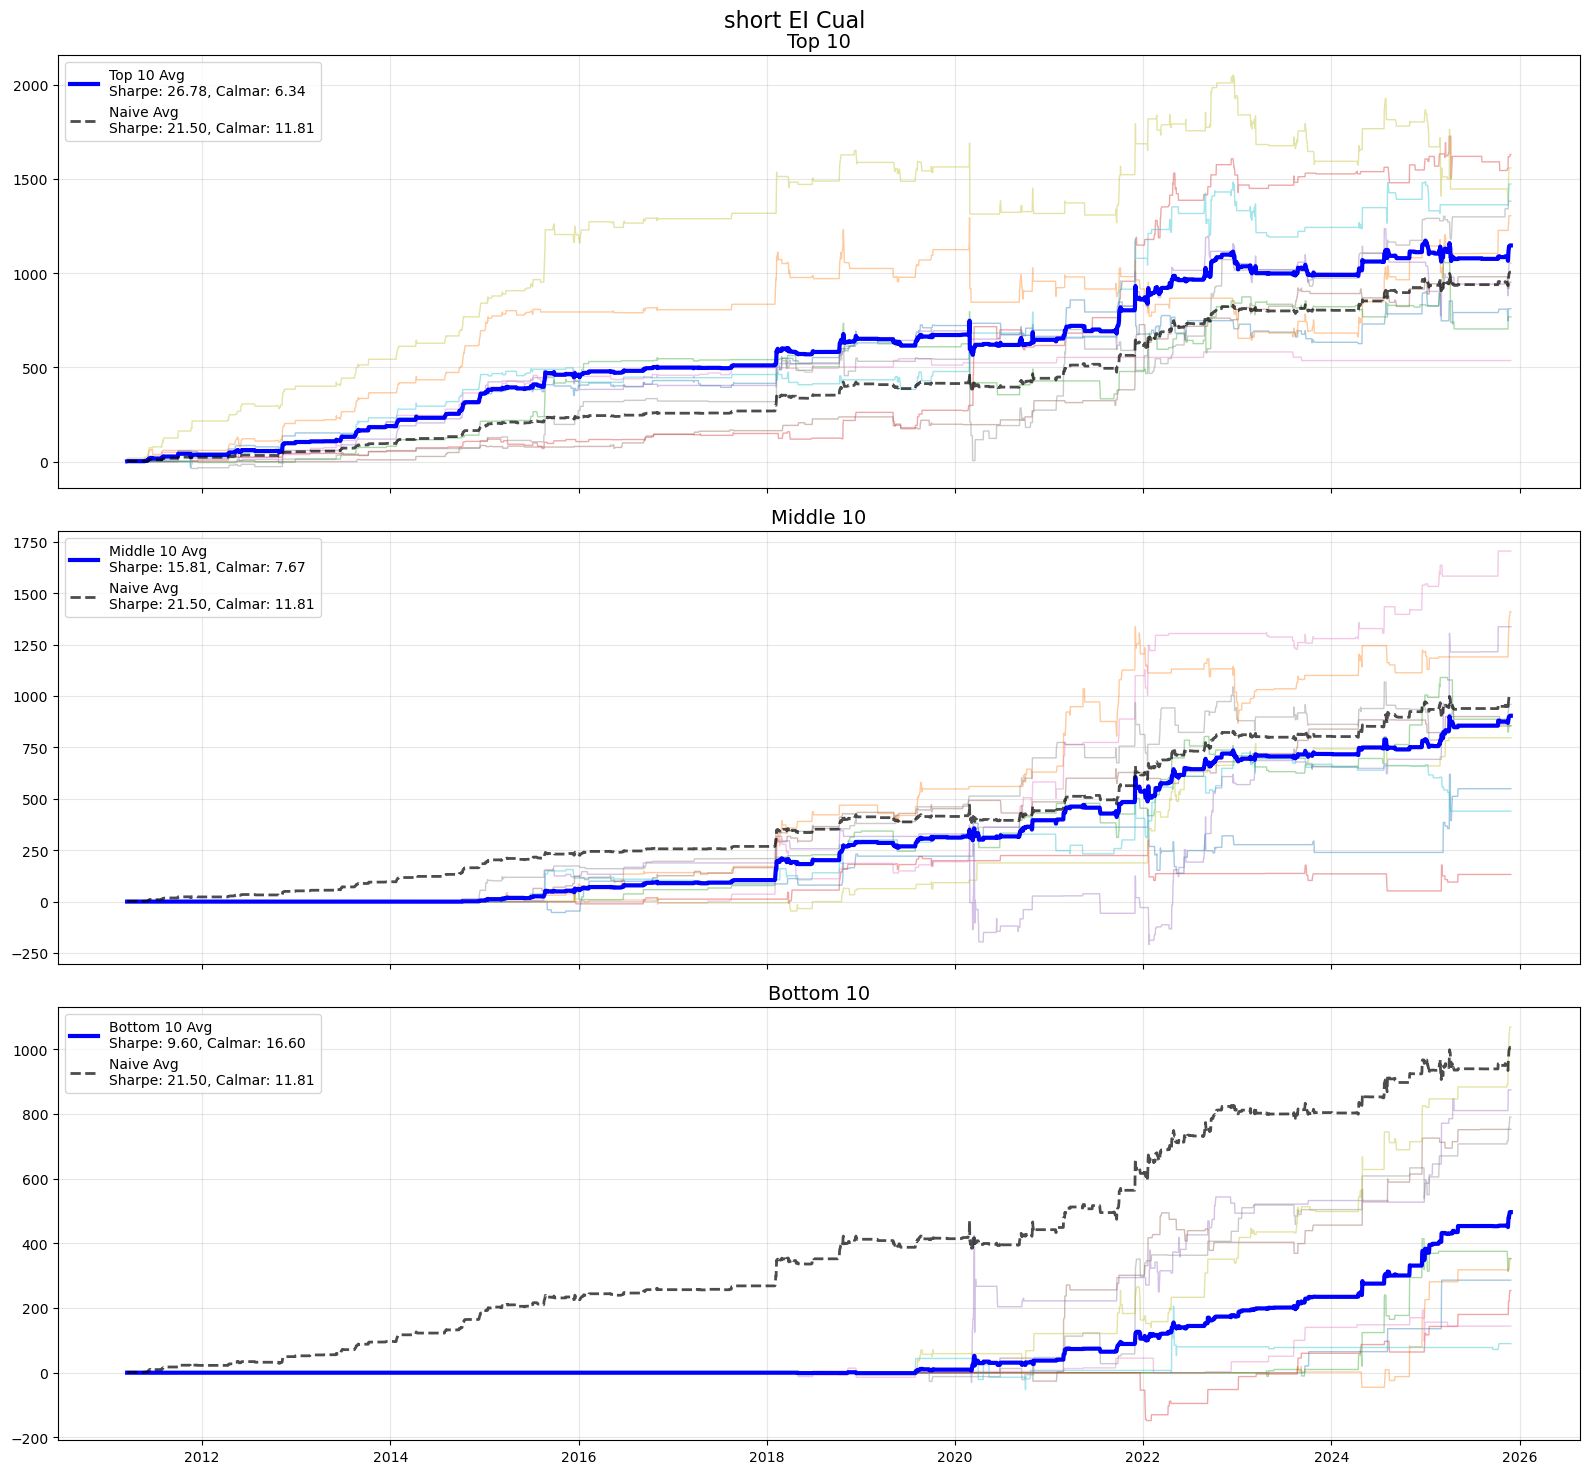

In [66]:
filter = cual_EI.drop(index=['naive_ave_pnl'])
top10 = filter.nlargest(10).index
mid10 = filter.nlargest(65).index.difference(filter.nlargest(55).index)
bottom10 = filter.nsmallest(10).index

plot_group(top10, mid10, bottom10, short, 'short EI Cual')

/var/folders/x0/47gb5md96sdcz2ww8mdbxprh0000gn/T/ipykernel_3794/2649286679.py:10: RuntimeWarning: invalid value encountered in divide
  out = np.where(rstd == 0, np.nan, rmean / rstd * np.sqrt(252))
/var/folders/x0/47gb5md96sdcz2ww8mdbxprh0000gn/T/ipykernel_3794/2649286679.py:19: RuntimeWarning: invalid value encountered in divide
  out = np.where(mdd != 0, arr / mdd, np.nan)
/var/folders/x0/47gb5md96sdcz2ww8mdbxprh0000gn/T/ipykernel_3794/2649286679.py:10: RuntimeWarning: divide by zero encountered in divide
  out = np.where(rstd == 0, np.nan, rmean / rstd * np.sqrt(252))
/var/folders/x0/47gb5md96sdcz2ww8mdbxprh0000gn/T/ipykernel_3794/2649286679.py:19: RuntimeWarning: divide by zero encountered in divide
  out = np.where(mdd != 0, arr / mdd, np.nan)
/var/folders/x0/47gb5md96sdcz2ww8mdbxprh0000gn/T/ipykernel_3794/2649286679.py:10: RuntimeWarning: invalid value encountered in divide
  out = np.where(rstd == 0, np.nan, rmean / rstd * np.sqrt(252))
/var/folders/x0/47gb5md96sdcz2ww8mdbxprh0

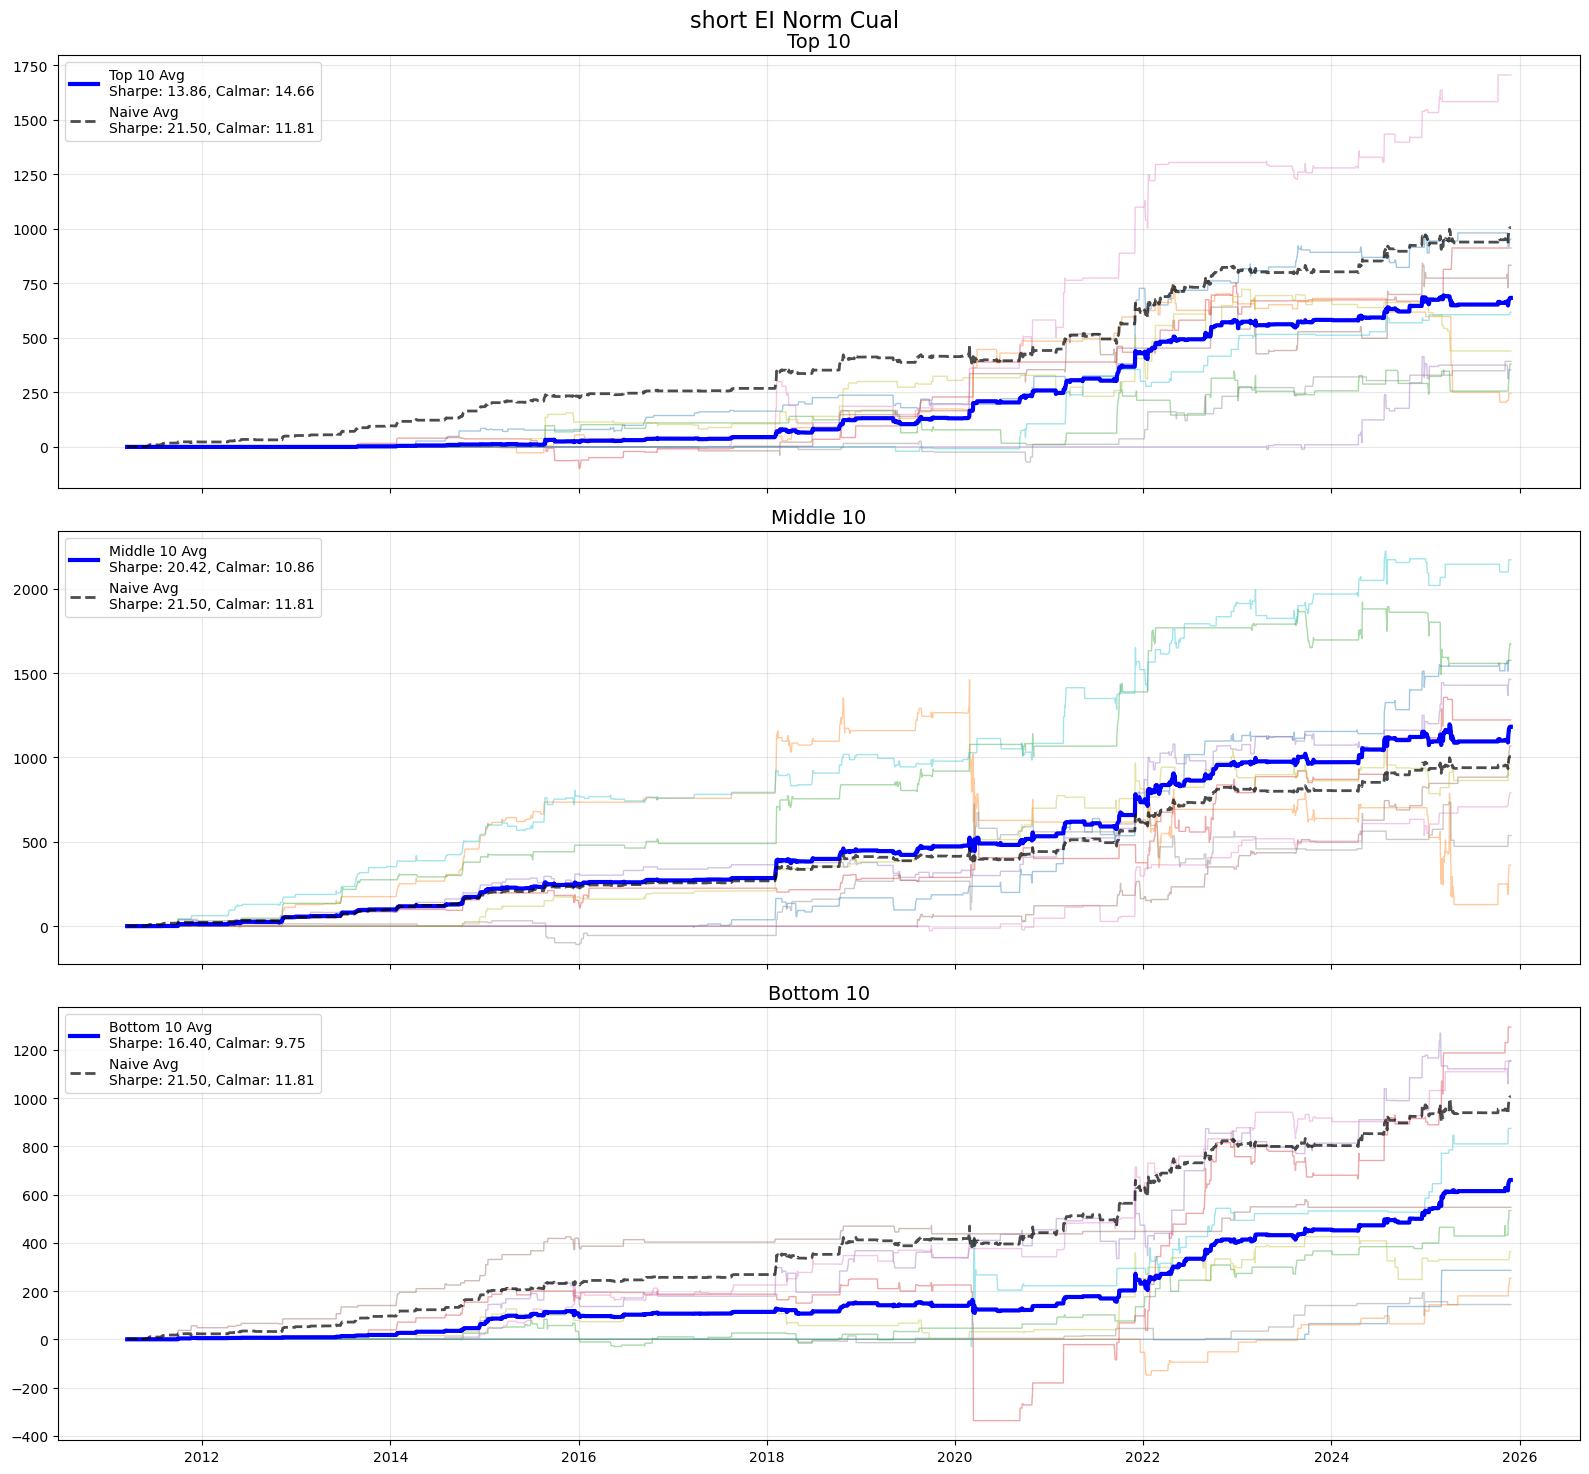

In [67]:
filter = norm_cual.drop(index=['naive_ave_pnl'])
top10 = filter.nlargest(10).index
mid10 = filter.nlargest(65).index.difference(filter.nlargest(55).index)
bottom10 = filter.nsmallest(10).index

plot_group(top10, mid10, bottom10, short, 'short EI Norm Cual')

## Clustering (Group by PnL)

In [68]:
from sklearn.cluster import KMeans, SpectralClustering, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

In [139]:
def evaluate_clustering(pnl, X, labels, name):
    df = pd.DataFrame({"cluster": labels, "EI_final": X[:, 0], "EI_AUC": X[:, 1], "EI_Ave": X[:, 2], "cual_EI": X[:, 3], "norm_cual": X[:, 4]})
    EI_by_cluster = df.groupby("cluster")["EI_final"].mean()
    EIauc_by_cluster = df.groupby("cluster")["EI_AUC"].mean()
    EIave_by_cluster = df.groupby("cluster")["EI_Ave"].mean()
    EIcual_by_cluster = df.groupby("cluster")["cual_EI"].mean()
    normcual_by_cluster = df.groupby("cluster")["norm_cual"].mean()

    if name == 'DTW':
        sil = silhouette_score(pnl, labels, metric="precomputed")
    else:
        sil = silhouette_score(pnl, labels)

    print(f"\n===== {name} =====")
    print("Cluster final EI means:")
    print(EI_by_cluster)
    print("Cluster EI AUC means:")
    print(EIauc_by_cluster)
    print("Cluster EI Ave means:")
    print(EIave_by_cluster)
    #print("Cluster EI cual means:")
    #print(EIcual_by_cluster)
    print("Cluster norm cual means:")
    print(normcual_by_cluster)

    print(f"\nSilhouette Score: {sil:.4f}\n")
    return EI_by_cluster, EIauc_by_cluster, EIave_by_cluster, sil

def run_all_clusterings(X, df, n):
    results = {}

    pnl = df.values.T # trader * time points
    km = KMeans(n_clusters=n, random_state=42)
    km_labels = km.fit_predict(pnl)
    results["kmeans"] = evaluate_clustering(pnl, X, km_labels, "KMeans")

    return km_labels, results

### long

In [140]:
EI_final = long_EI.iloc[-1]
EI_AUC = long_EI.cumsum().iloc[-1]
EI_Ave = long_EI.replace(0, np.nan).mean()

annual_last = long_EI.resample('1Y').last()
cual_EI = annual_last.cumsum().iloc[-1]
nonzero_years = (annual_last != 0).sum()
norm_cual = cual_EI / nonzero_years

X = np.column_stack([
    EI_final.values,
    EI_AUC.values,
    EI_Ave.values,
    cual_EI.values,
    norm_cual.values,

])

labels, result = run_all_clusterings(X, long.drop(columns=['price']), n = 3)


===== KMeans =====
Cluster final EI means:
cluster
0    0.587242
1    0.606910
2    0.620860
Name: EI_final, dtype: float64
Cluster EI AUC means:
cluster
0    18.660468
1    16.570137
2    32.241381
Name: EI_AUC, dtype: float64
Cluster EI Ave means:
cluster
0    0.430200
1    0.413198
2    0.405109
Name: EI_Ave, dtype: float64
Cluster norm cual means:
cluster
0    0.443080
1    0.472009
2    0.423579
Name: norm_cual, dtype: float64

Silhouette Score: 0.3809



/var/folders/x0/47gb5md96sdcz2ww8mdbxprh0000gn/T/ipykernel_3794/3498010253.py:5: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  annual_last = long_EI.resample('1Y').last()


In [72]:
long_cols = long.drop(columns=['price']).columns
top = long_cols[labels == 2]
mid = long_cols[labels == 0]
bottom = long_cols[labels == 1]

In [73]:
print(f'\nLong top: \nfinal EI: {EI_final[top].mean().round(2)}, \nEI AUC: {EI_AUC[top].mean().round(2)}, \nEI Ave:{EI_Ave[top].mean().round(2)}, \nEI Cual:{cual_EI[top].mean().round(2)}, \nEI Norm Cual:{norm_cual[top].mean().round(2)}')
print(f'\nLong mid: \nfinal EI: {EI_final[mid].mean().round(2)}, \nEI AUC: {EI_AUC[mid].mean().round(2)}, \nEI Ave:{EI_Ave[mid].mean().round(2)}, \nEI Cual:{cual_EI[mid].mean().round(2)}, \nEI Norm Cual:{norm_cual[mid].mean().round(2)}')
print(f'\nLong bottom: \nfinal EI: {EI_final[bottom].mean().round(2)}, \nEI AUC: {EI_AUC[bottom].mean().round(2)}, \nEI Ave:{EI_Ave[bottom].mean().round(2)}, \nEI Cual:{cual_EI[bottom].mean().round(2)}, \nEI Norm Cual:{norm_cual[bottom].mean().round(2)}')


Long top: 
final EI: 0.62, 
EI AUC: 32.24, 
EI Ave:0.41, 
EI Cual:2.96, 
EI Norm Cual:0.42

Long mid: 
final EI: 0.59, 
EI AUC: 18.66, 
EI Ave:0.43, 
EI Cual:1.85, 
EI Norm Cual:0.44

Long bottom: 
final EI: 0.61, 
EI AUC: 16.57, 
EI Ave:0.41, 
EI Cual:1.75, 
EI Norm Cual:0.47


77_long 134_long 78_long


/var/folders/x0/47gb5md96sdcz2ww8mdbxprh0000gn/T/ipykernel_3794/2649286679.py:10: RuntimeWarning: invalid value encountered in divide
  out = np.where(rstd == 0, np.nan, rmean / rstd * np.sqrt(252))
/var/folders/x0/47gb5md96sdcz2ww8mdbxprh0000gn/T/ipykernel_3794/2649286679.py:19: RuntimeWarning: divide by zero encountered in divide
  out = np.where(mdd != 0, arr / mdd, np.nan)
/var/folders/x0/47gb5md96sdcz2ww8mdbxprh0000gn/T/ipykernel_3794/2649286679.py:19: RuntimeWarning: invalid value encountered in divide
  out = np.where(mdd != 0, arr / mdd, np.nan)
/var/folders/x0/47gb5md96sdcz2ww8mdbxprh0000gn/T/ipykernel_3794/2649286679.py:10: RuntimeWarning: divide by zero encountered in divide
  out = np.where(rstd == 0, np.nan, rmean / rstd * np.sqrt(252))


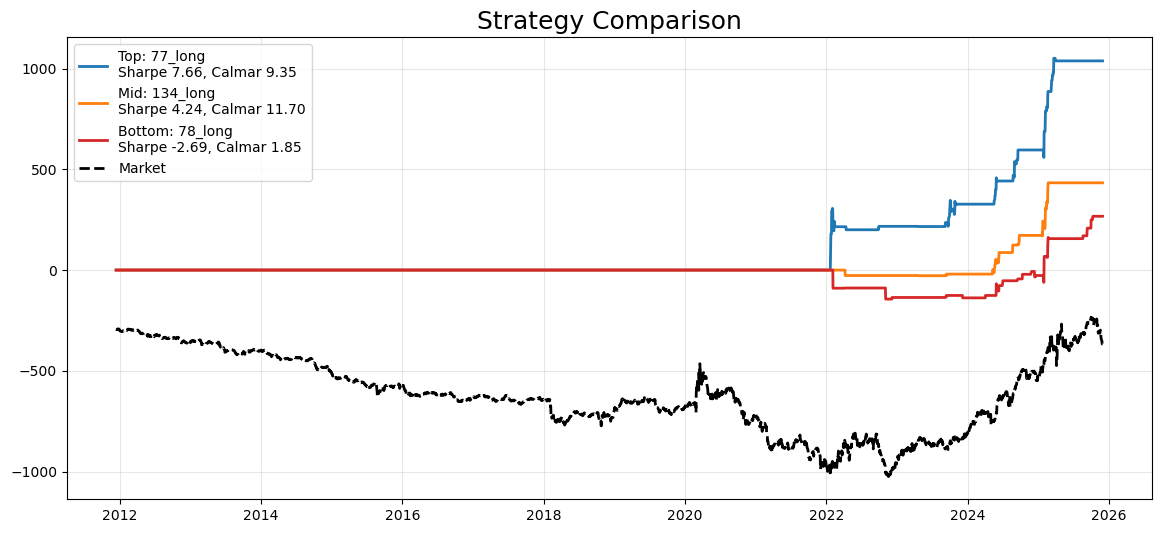

In [76]:
# 颜色设置
colors = {
    "top":   "#1f77b4",    # 蓝
    "mid":   "#ff7f0e",    # 橙
    "bottom":"#d62728",    # 红
    "market":"#000000",    # 黑
}

rng = np.random.default_rng()
col1 = rng.choice(top)
col2 = rng.choice(mid)
col3 = rng.choice(bottom)

print(col1, col2, col3)

plt.figure(figsize=(14, 6))

df0 = long

# --------------------------
# 辅助函数：生成标签（含 Sharpe & Calmar）
# --------------------------
def metric_label(name, series):
    s = sharpe_ratio(series)[-1]
    c = calmar(series)[-1]
    if name == "Market":
        return f"{name}"
    return f"{name}: {series.name}\nSharpe {s:.2f}, Calmar {c:.2f}"

# --------------------------
# Top
# --------------------------
plt.plot(
    df0.index,
    df0[col1],
    label=metric_label("Top", df0[col1]),
    color=colors["top"],
    linewidth=2
)

# --------------------------
# Mid
# --------------------------
plt.plot(
    df0.index,
    df0[col2],
    label=metric_label("Mid", df0[col2]),
    color=colors["mid"],
    linewidth=2
)

# --------------------------
# Bottom
# --------------------------
plt.plot(
    df0.index,
    df0[col3],
    label=metric_label("Bottom", df0[col3]),
    color=colors["bottom"],
    linewidth=2
)

# --------------------------
# Market Baseline
# --------------------------
plt.plot(
    df0.index,
    df0["price"],
    label=metric_label("Market", df0["price"]),
    color=colors["market"],
    linewidth=2,
    linestyle="--"
)

plt.legend()
plt.grid(alpha=0.3)
plt.title("Strategy Comparison", fontsize=18)
plt.show()


### Short

In [141]:
EI_final = short_EI.iloc[-1]
EI_AUC = short_EI.cumsum().iloc[-1]
EI_Ave = short_EI.replace(0, np.nan).mean()

annual_last = short_EI.resample('1Y').last()
cual_EI = annual_last.cumsum().iloc[-1]
nonzero_years = (annual_last != 0).sum()
norm_cual = cual_EI / nonzero_years

X = np.column_stack([
    EI_final.values,
    EI_AUC.values,
    EI_Ave.values,
    cual_EI.values,
    norm_cual.values,
])

labels, result = run_all_clusterings(X, short.drop(columns=['price']), n = 3)


===== KMeans =====
Cluster final EI means:
cluster
0    0.628942
1    0.521228
2    0.573711
Name: EI_final, dtype: float64
Cluster EI AUC means:
cluster
0    47.897897
1    81.653226
2    72.679359
Name: EI_AUC, dtype: float64
Cluster EI Ave means:
cluster
0    0.469490
1    0.478433
2    0.470140
Name: EI_Ave, dtype: float64
Cluster norm cual means:
cluster
0    0.482881
1    0.482947
2    0.476691
Name: norm_cual, dtype: float64

Silhouette Score: 0.3986



/var/folders/x0/47gb5md96sdcz2ww8mdbxprh0000gn/T/ipykernel_3794/2288600942.py:5: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  annual_last = short_EI.resample('1Y').last()


In [78]:
short_cols = short.drop(columns=['price']).columns
top = short_cols[labels == 1]
mid = short_cols[labels == 2]
bottom = short_cols[labels == 0]


print(f'\nShort top: \nfinal EI: {EI_final[top].mean().round(2)}, \nEI AUC: {EI_AUC[top].mean().round(2)}, \nEI Ave:{EI_Ave[top].mean().round(2)}, \nEI Cual:{cual_EI[top].mean().round(2)}, \nEI Norm Cual:{norm_cual[top].mean().round(2)}')
print(f'\nShort mid: \nfinal EI: {EI_final[mid].mean().round(2)}, \nEI AUC: {EI_AUC[mid].mean().round(2)}, \nEI Ave:{EI_Ave[mid].mean().round(2)}, \nEI Cual:{cual_EI[mid].mean().round(2)}, \nEI Norm Cual:{norm_cual[mid].mean().round(2)}')
print(f'\nShort bottom: \nfinal EI: {EI_final[bottom].mean().round(2)}, \nEI AUC: {EI_AUC[bottom].mean().round(2)}, \nEI Ave:{EI_Ave[bottom].mean().round(2)}, \nEI Cual:{cual_EI[bottom].mean().round(2)}, \nEI Norm Cual:{norm_cual[bottom].mean().round(2)}')


Short top: 
final EI: 0.52, 
EI AUC: 81.65, 
EI Ave:0.48, 
EI Cual:7.08, 
EI Norm Cual:0.48

Short mid: 
final EI: 0.57, 
EI AUC: 72.68, 
EI Ave:0.47, 
EI Cual:6.4, 
EI Norm Cual:0.48

Short bottom: 
final EI: 0.63, 
EI AUC: 47.9, 
EI Ave:0.47, 
EI Cual:4.38, 
EI Norm Cual:0.48


100_short 59_short 82_short


/var/folders/x0/47gb5md96sdcz2ww8mdbxprh0000gn/T/ipykernel_3794/2649286679.py:10: RuntimeWarning: divide by zero encountered in divide
  out = np.where(rstd == 0, np.nan, rmean / rstd * np.sqrt(252))
/var/folders/x0/47gb5md96sdcz2ww8mdbxprh0000gn/T/ipykernel_3794/2649286679.py:19: RuntimeWarning: divide by zero encountered in divide
  out = np.where(mdd != 0, arr / mdd, np.nan)
/var/folders/x0/47gb5md96sdcz2ww8mdbxprh0000gn/T/ipykernel_3794/2649286679.py:10: RuntimeWarning: invalid value encountered in divide
  out = np.where(rstd == 0, np.nan, rmean / rstd * np.sqrt(252))
/var/folders/x0/47gb5md96sdcz2ww8mdbxprh0000gn/T/ipykernel_3794/2649286679.py:19: RuntimeWarning: invalid value encountered in divide
  out = np.where(mdd != 0, arr / mdd, np.nan)


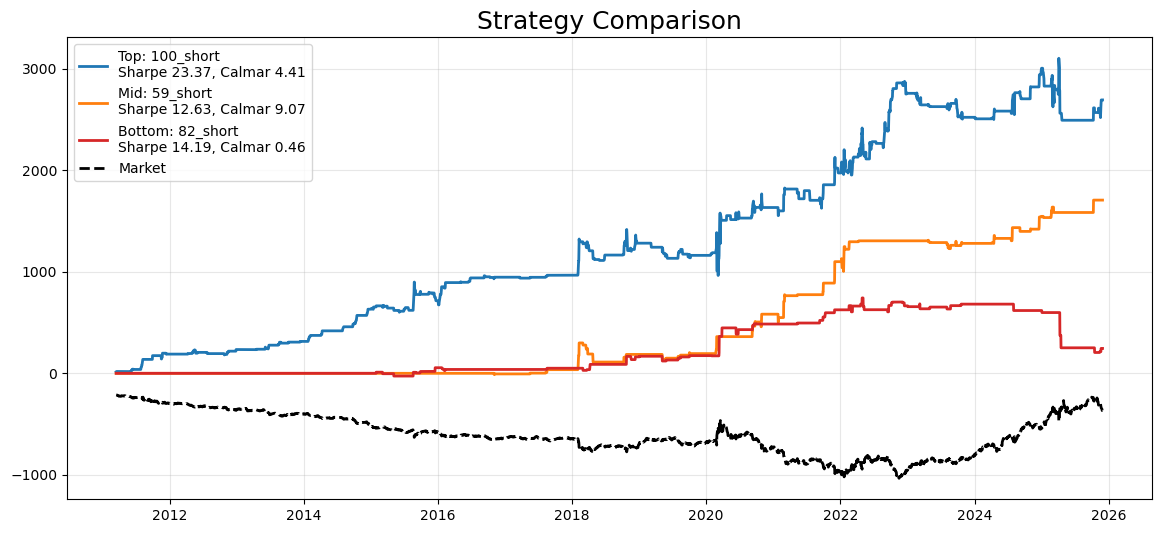

In [79]:
# 颜色设置
colors = {
    "top":   "#1f77b4",    # 蓝
    "mid":   "#ff7f0e",    # 橙
    "bottom":"#d62728",    # 红
    "market":"#000000",    # 黑
}

rng = np.random.default_rng()
col1 = rng.choice(top)
col2 = rng.choice(mid)
col3 = rng.choice(bottom)

print(col1, col2, col3)

plt.figure(figsize=(14, 6))

df0 = short

# --------------------------
# 辅助函数：生成标签（含 Sharpe & Calmar）
# --------------------------
def metric_label(name, series):
    s = sharpe_ratio(series)[-1]
    c = calmar(series)[-1]
    if name == "Market":
        return f"{name}"
    return f"{name}: {series.name}\nSharpe {s:.2f}, Calmar {c:.2f}"

# --------------------------
# Top
# --------------------------
plt.plot(
    df0.index,
    df0[col1],
    label=metric_label("Top", df0[col1]),
    color=colors["top"],
    linewidth=2
)

# --------------------------
# Mid
# --------------------------
plt.plot(
    df0.index,
    df0[col2],
    label=metric_label("Mid", df0[col2]),
    color=colors["mid"],
    linewidth=2
)

# --------------------------
# Bottom
# --------------------------
plt.plot(
    df0.index,
    df0[col3],
    label=metric_label("Bottom", df0[col3]),
    color=colors["bottom"],
    linewidth=2
)

# --------------------------
# Market Baseline
# --------------------------
plt.plot(
    df0.index,
    df0["price"],
    label=metric_label("Market", df0["price"]),
    color=colors["market"],
    linewidth=2,
    linestyle="--"
)

plt.legend()
plt.grid(alpha=0.3)
plt.title("Strategy Comparison", fontsize=18)
plt.show()
